In [2]:
import os
import random
import shutil

import cv2
import gdown
import matplotlib.pyplot as plt
import numpy as np
import rasterio
from sklearn.metrics import classification_report, confusion_matrix, f1_score
from sklearn.model_selection import train_test_split

import tensorflow as tf
from tensorflow.keras import backend as K
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.layers import (
    Activation, BatchNormalization, Conv2D, Conv2DTranspose,
    Dropout, Input, MaxPooling2D, concatenate
)
from tensorflow.keras.models import Model

In [3]:
source = "/content/drive/MyDrive/satalite data/data"

destination = "/content/SatelliteDataset"

shutil.copytree(source, destination)



'/content/SatelliteDataset'

In [4]:
with rasterio.open("/content/SatelliteDataset/images/0.tif") as src:
    print("Bands:", src.count)
    print("Shape:", src.height, src.width)

Bands: 12
Shape: 128 128


/usr/local/lib/python3.12/dist-packages/rasterio/__init__.py:367: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset = DatasetReader(path, driver=driver, sharing=sharing, thread_safe=thread_safe, **kwargs)


In [5]:
def preview_satellite_image_grid(image_path):

    with rasterio.open(image_path) as src:
        image = src.read()  # shape: (12, H, W)

    band_names = [
        "Coastal", "Blue", "Green", "Red",
        "NIR", "SWIR1", "SWIR2",
        "QA Band", "Merit DEM", "Copernicus DEM",
        "ESA World Cover", "Water Occurrence Probability"
    ]

    # Prepare figure
    fig, axes = plt.subplots(2, 5, figsize=(25, 10))
    axes = axes.flatten()

    rgb = image[[3,2,1]].astype(np.float32)
    for c in range(3):
        band = rgb[c]
        rgb[c] = (band - band.min()) / (band.max() - band.min())
    rgb = np.transpose(rgb, (1,2,0))

    axes[0].imshow(rgb)
    axes[0].set_title("RGB Composite")
    axes[0].axis("off")

    # Indices to show: 0, 4, 5, 6, 7, 8, 9, 10, 11
    channel_indices = [0, 4, 5, 6, 7, 8, 9, 10, 11]

    for ax_idx, i in enumerate(channel_indices, start=1):
        band = image[i].astype(np.float32)
        name = band_names[i]

        # Choose colormap and normalization
        if i <= 6:  # spectral bands
            band = (band - band.min()) / (band.max() - band.min())
            cmap = "Blues"
        elif i in [8,9]:  # DEMs
            band = (band - band.min()) / (band.max() - band.min())
            cmap = "Blues"
        elif i == 11:  # water probability
            band = band / 100.0
            cmap = "Blues"
        else:  # QA / World Cover
            cmap = "Blues"

        axes[ax_idx].imshow(band, cmap=cmap)
        axes[ax_idx].set_title(name)
        axes[ax_idx].axis("off")

    plt.tight_layout()
    plt.show()


Image : 0.tif


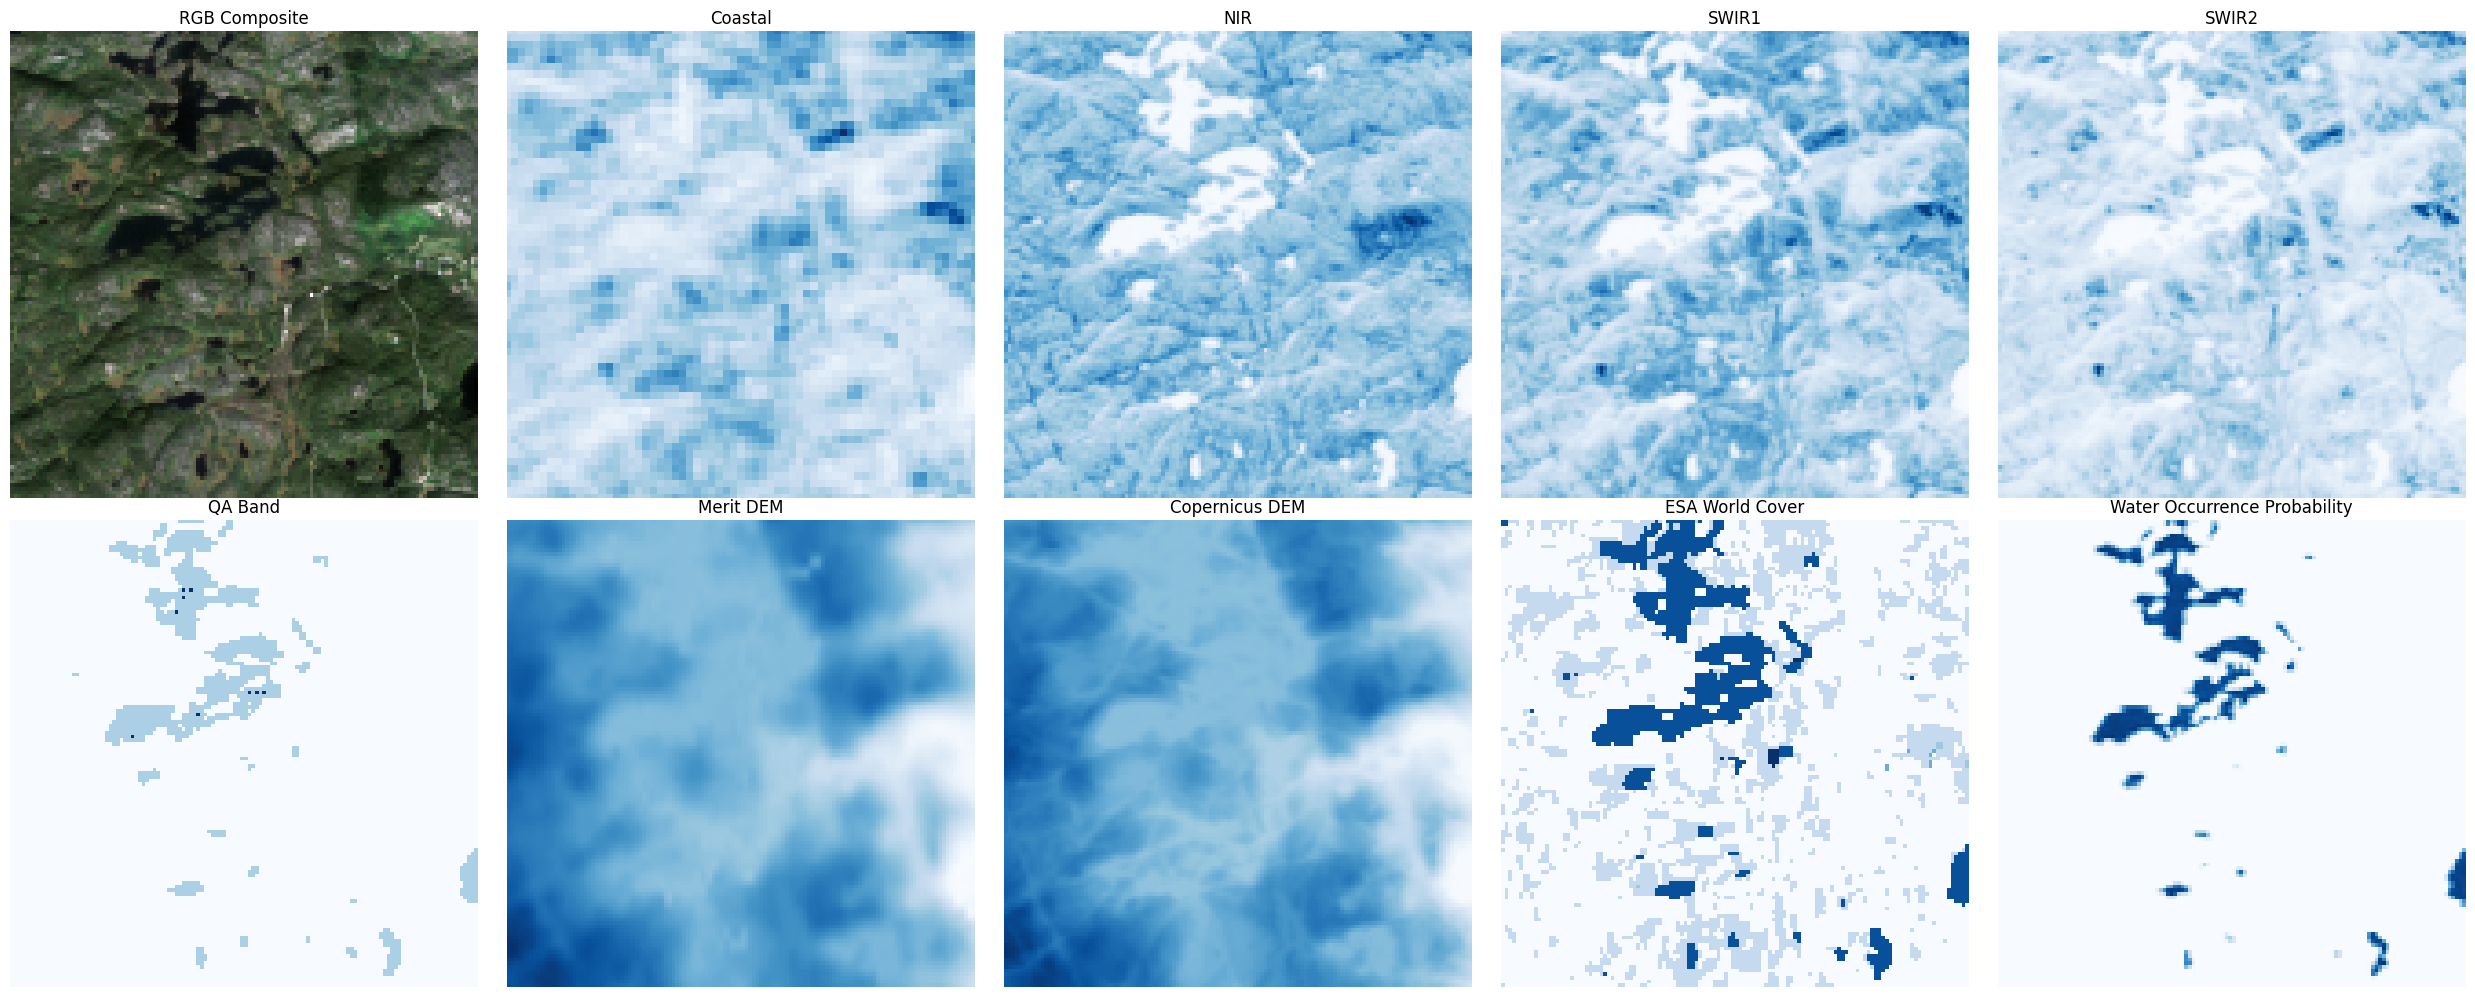



Image : 1.tif


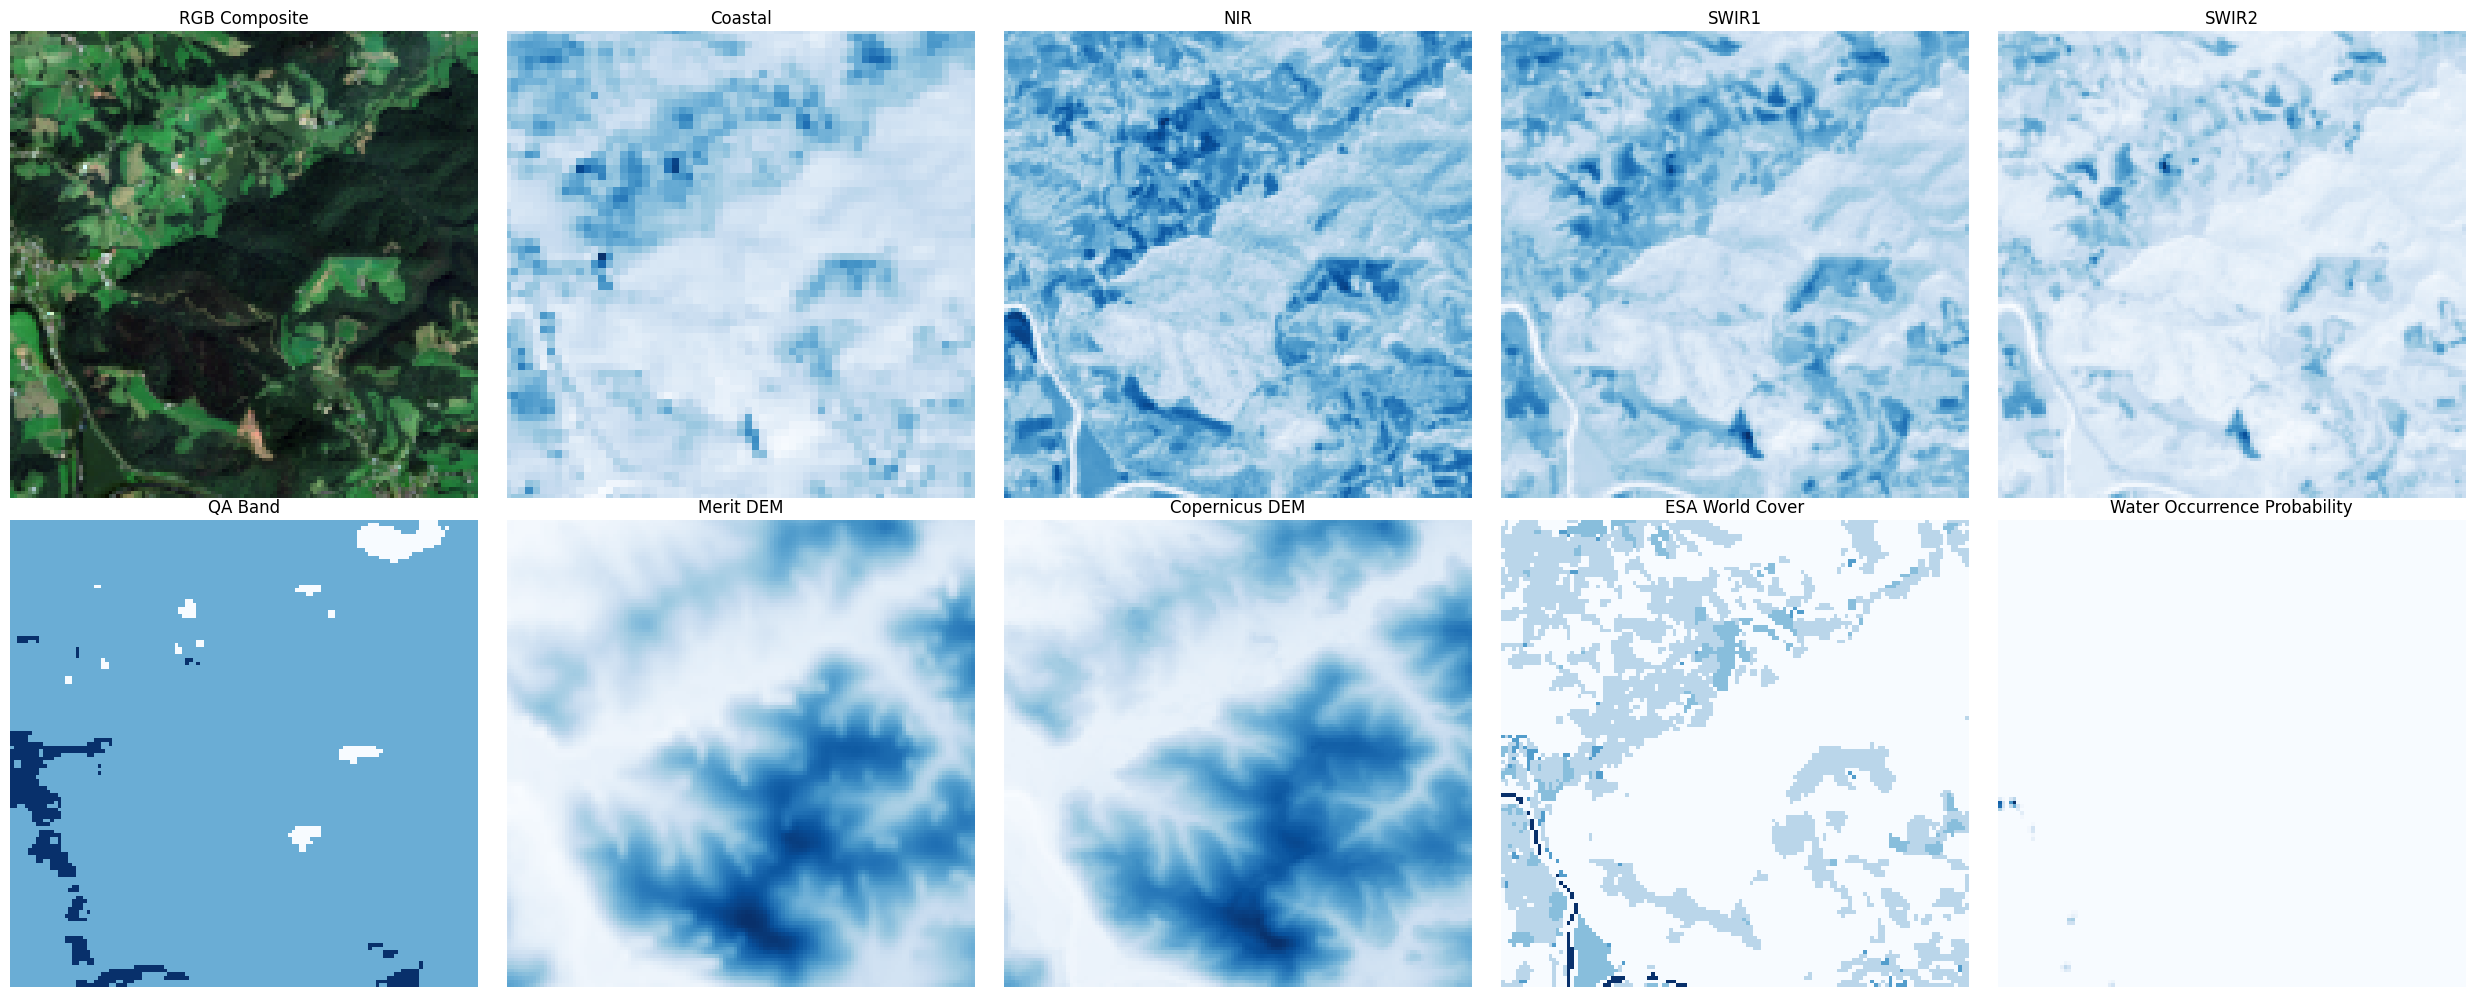



Image : 10.tif


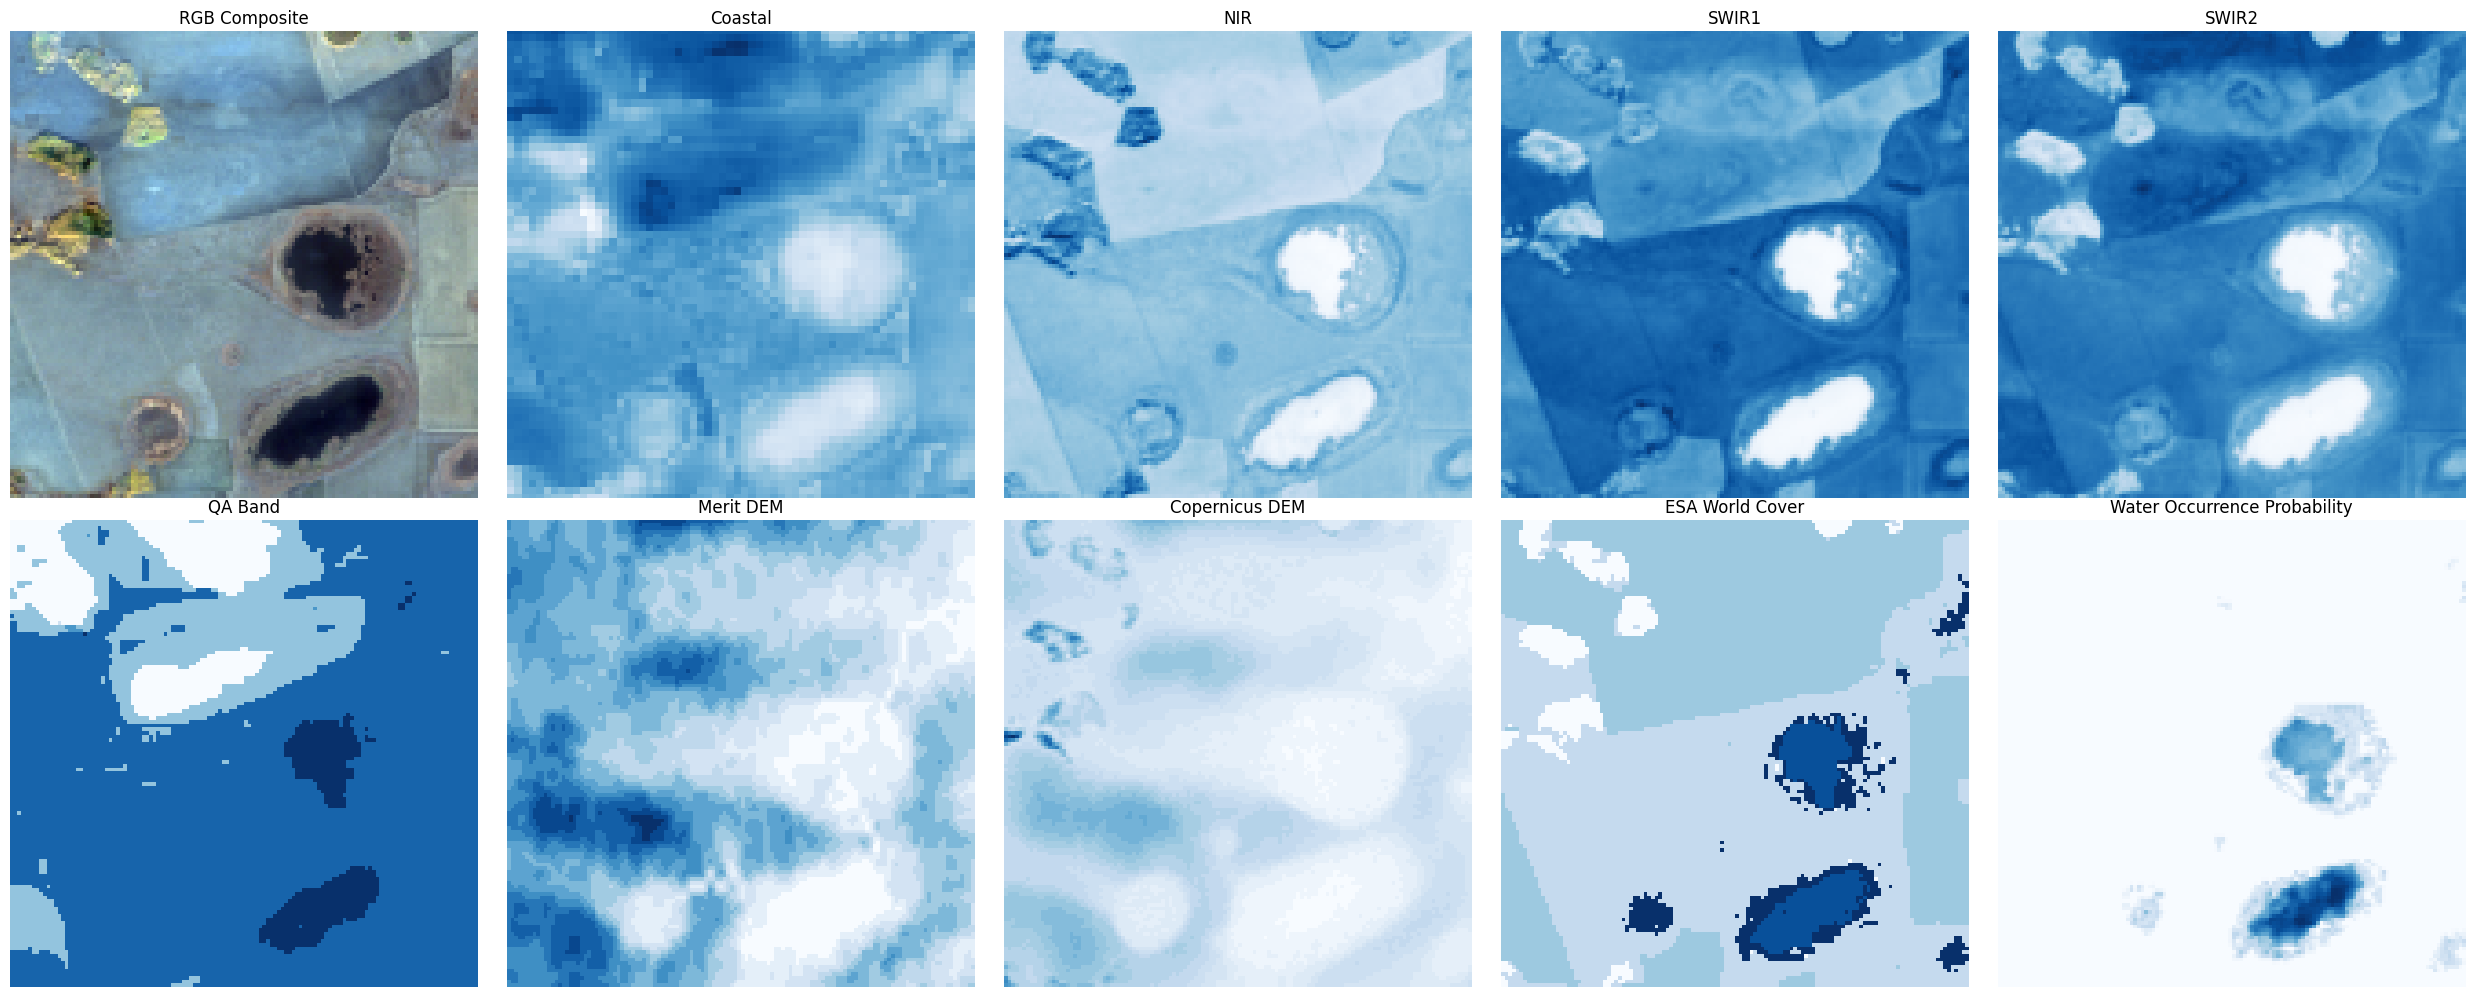



Image : 100.tif


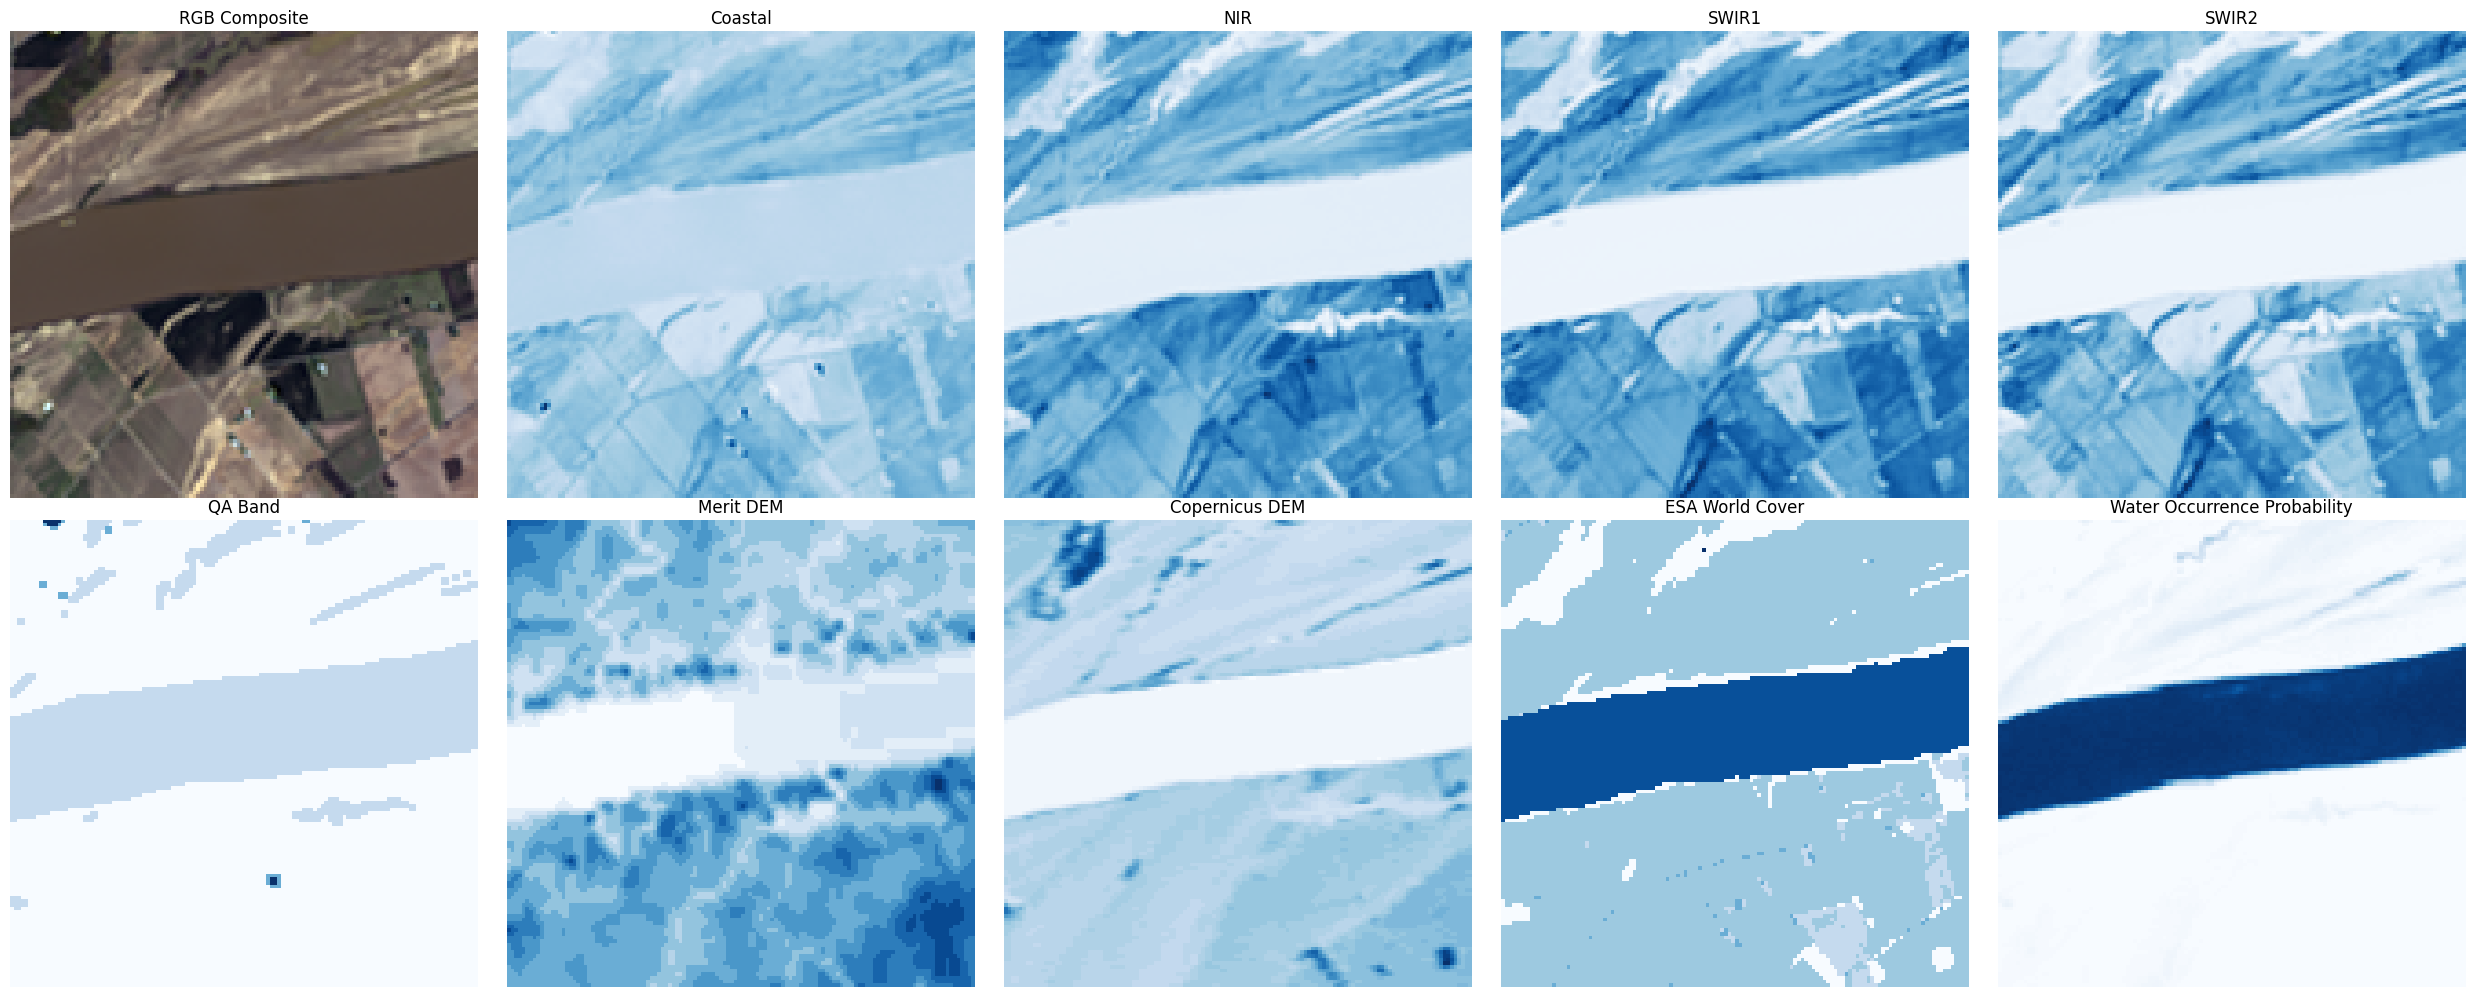



Image : 101.tif


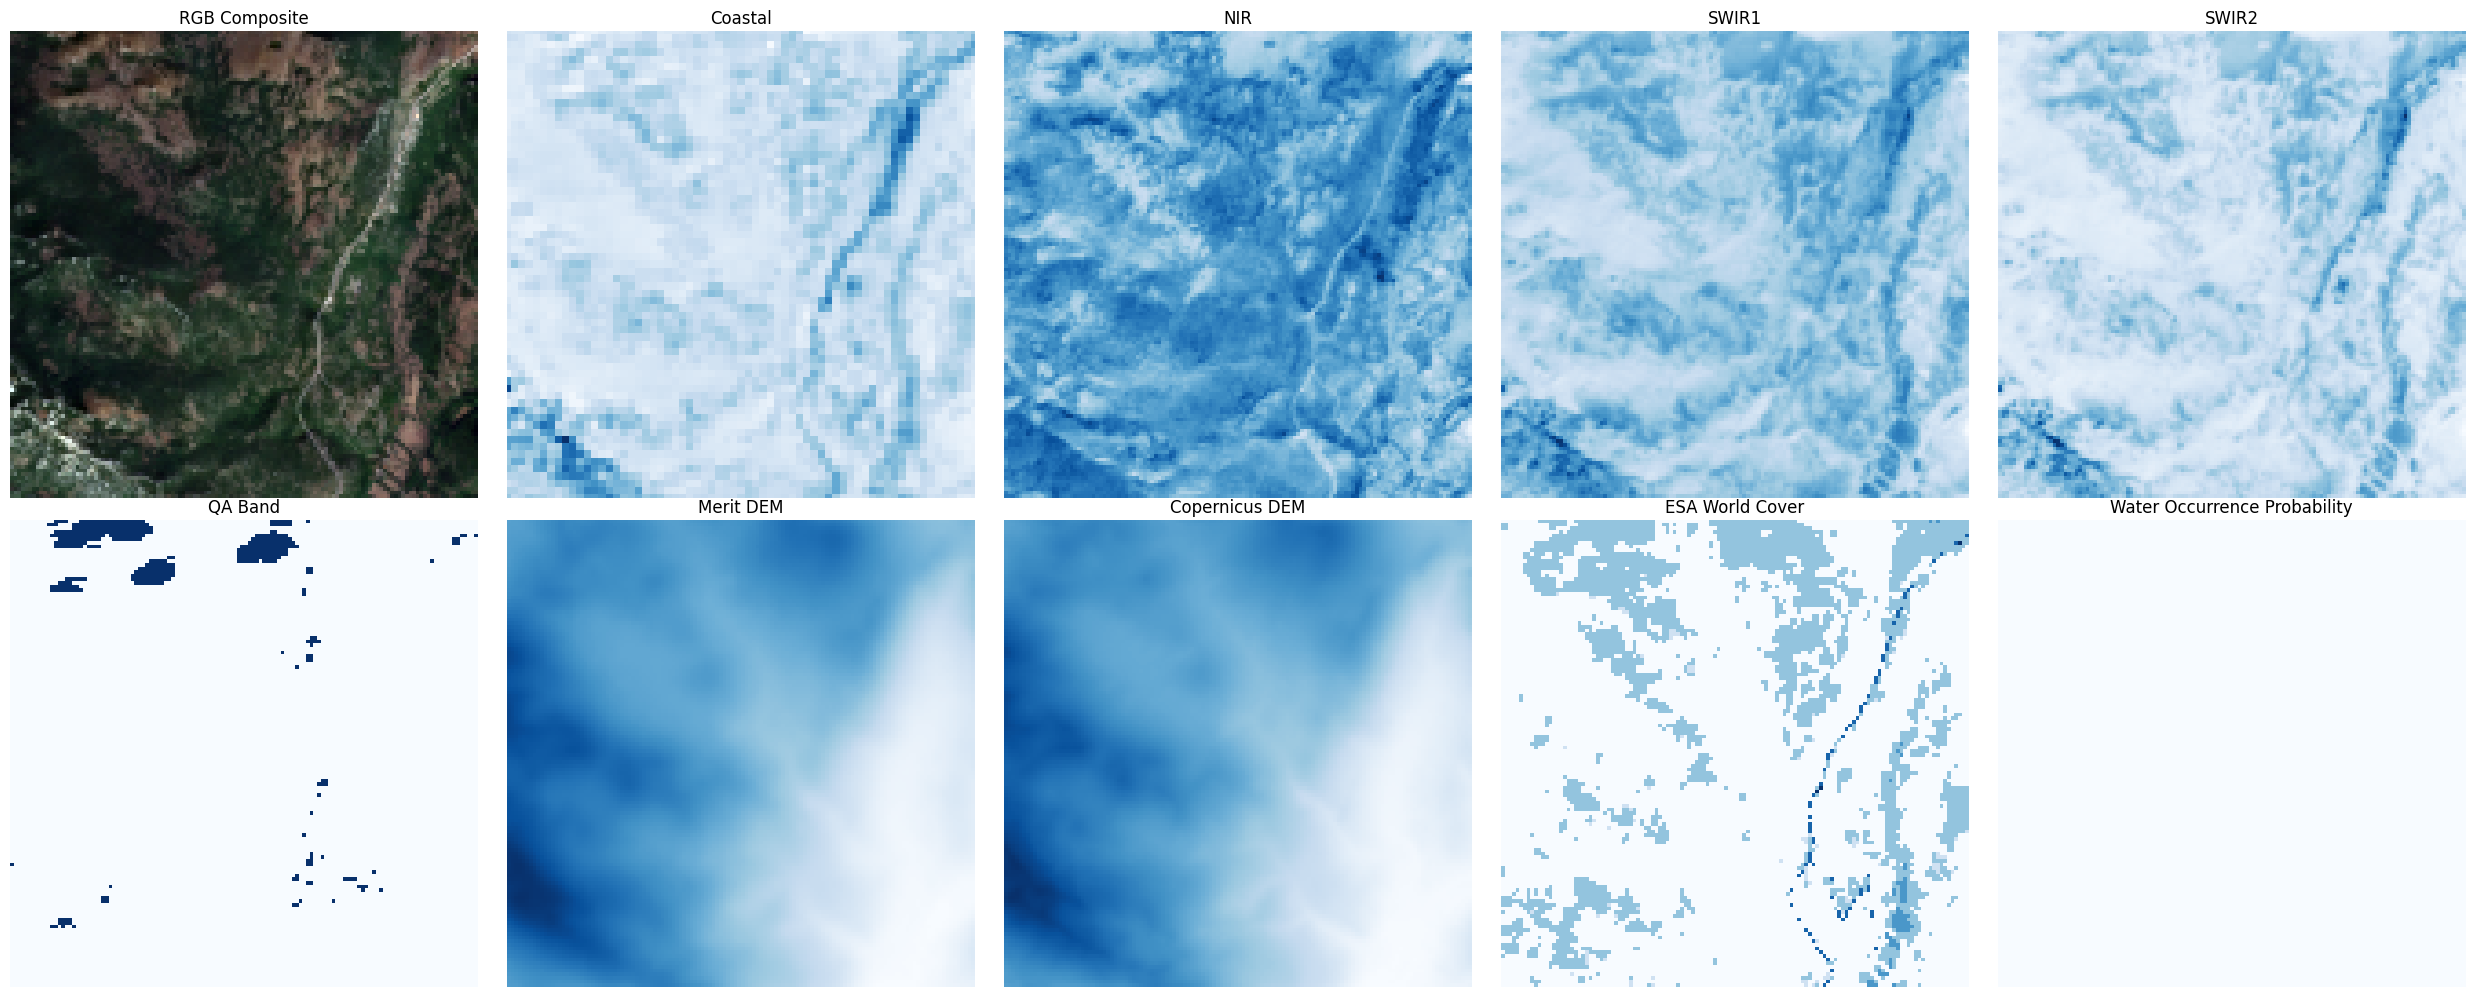

In [6]:
folder = "/content/SatelliteDataset/images"
files = sorted([f for f in os.listdir(folder) if f.endswith(".tif")])

# Preview first 3 images
for f in files[:5]:
  print(f"Image : {f}")
  preview_satellite_image_grid(os.path.join(folder, f))
  print("\n")


In [7]:
input_data = sorted(os.listdir("/content/SatelliteDataset/images"))
labels_data = sorted(os.listdir("/content/SatelliteDataset/labels"))

filtered_labels = []

for i in os.listdir("/content/SatelliteDataset/labels"):
  if not("_" in i):
    filtered_labels.append(i)


filtered_labels = sorted(filtered_labels)

print(f"TIF Count : {len(input_data)} ---- Masks Count : {len(filtered_labels)}")

for i in range(10):

  print(f"Trainging : {input_data[i]} ---- Label : {filtered_labels[i]}")


TIF Count : 306 ---- Masks Count : 306
Trainging : 0.tif ---- Label : 0.png
Trainging : 1.tif ---- Label : 1.png
Trainging : 10.tif ---- Label : 10.png
Trainging : 100.tif ---- Label : 100.png
Trainging : 101.tif ---- Label : 101.png
Trainging : 102.tif ---- Label : 102.png
Trainging : 103.tif ---- Label : 103.png
Trainging : 104.tif ---- Label : 104.png
Trainging : 105.tif ---- Label : 105.png
Trainging : 106.tif ---- Label : 106.png


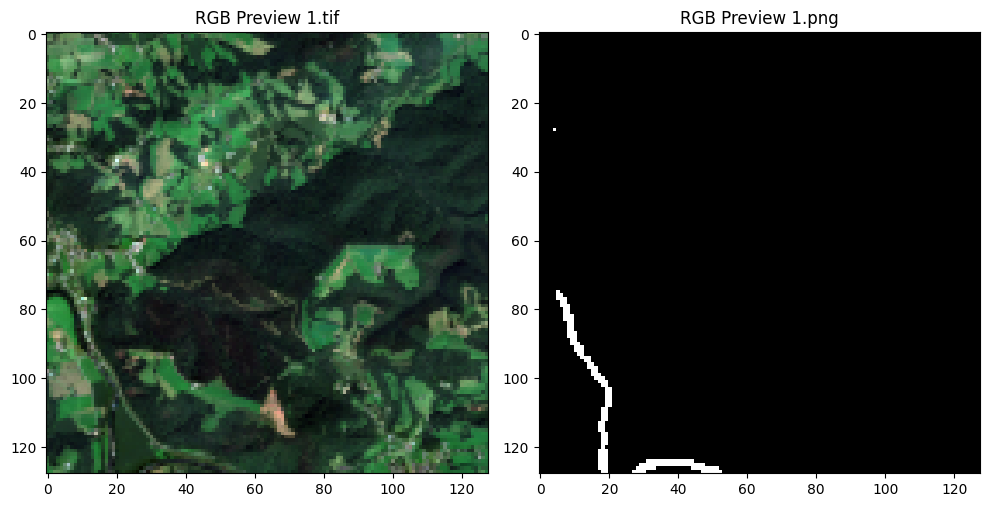

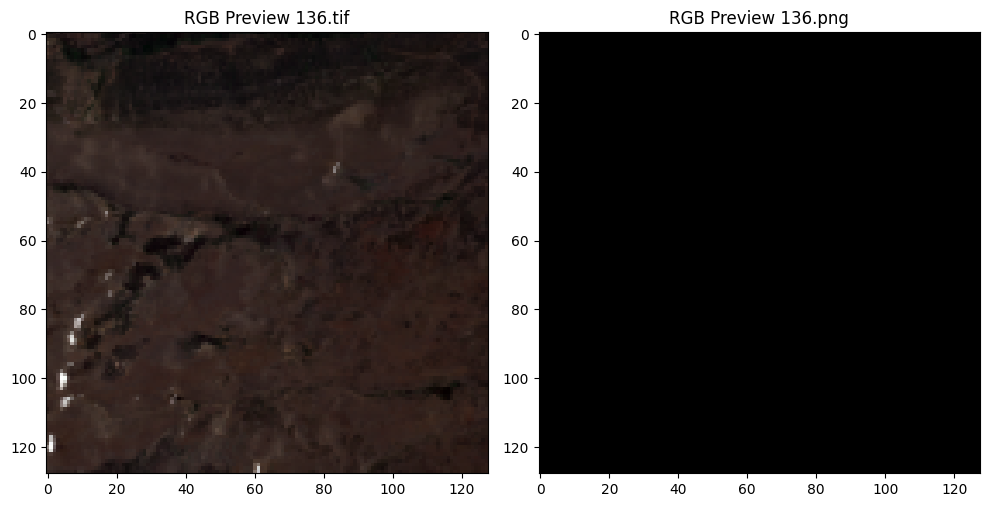

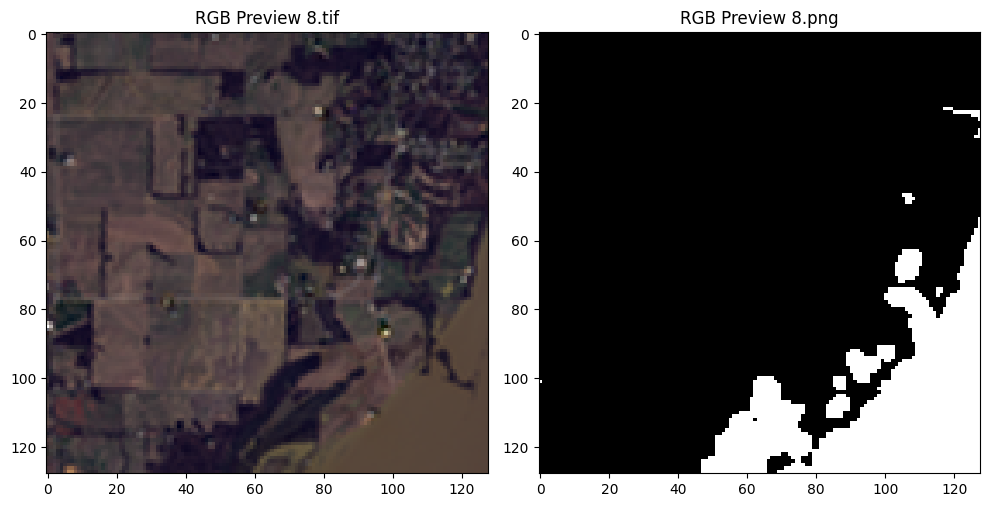

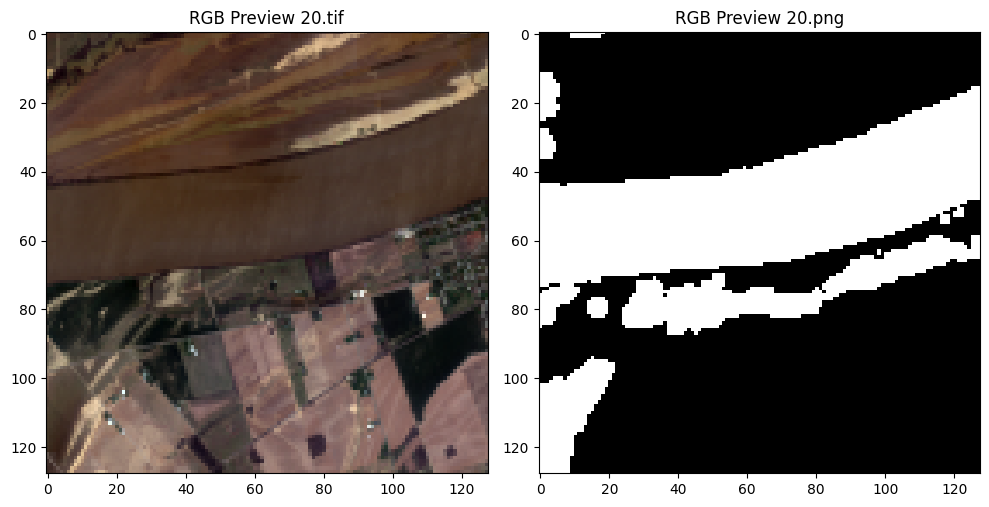

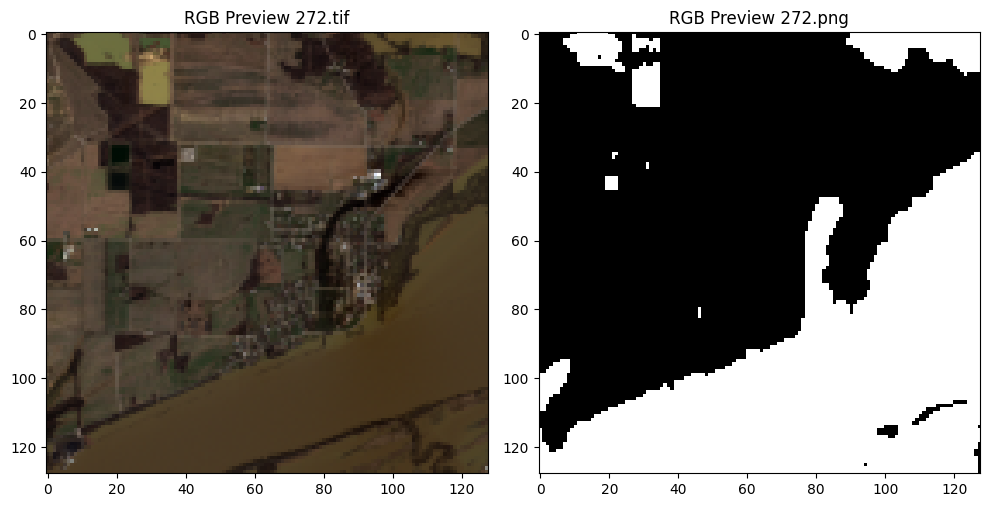

In [8]:
num_samples = 5


total_available = min(len(filtered_labels), len(input_data))
indices = random.sample(range(total_available), min(num_samples, total_available))


for i in indices:
    fig, axes = plt.subplots(1, 2, figsize=(10, 5))

    input_tif = input_data[i]
    input_png = filtered_labels[i]

    path_input = os.path.join("/content/SatelliteDataset/images" , input_tif)
    with rasterio.open(path_input) as src:
        image = src.read()

    # Normalize only RGB bands
    rgb = image[[3,2,1]].astype(np.float32)
    for c in range(3):
        band = rgb[c]
        rgb[c] = (band - band.min()) / (band.max() - band.min())
    rgb = np.transpose(rgb, (1, 2, 0))

    axes[0].imshow(rgb)
    axes[0].set_title(f"RGB Preview {input_tif}")

    path_png = os.path.join("/content/SatelliteDataset/labels" , input_png)

    img = cv2.imread(path_png)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = img * 255

    axes[1].imshow(img)
    axes[1].set_title(f"RGB Preview {input_png}")

    plt.tight_layout()
    plt.show()

In [38]:
IMAGE_DIR = "/content/SatelliteDataset/images"
LABEL_DIR = "/content/SatelliteDataset/labels"

SELECTED_CHANNELS = [1, 2, 3, 4, 5, 6]  # Blue, Green, Red, NIR, SWIR1, SWIR2

def compute_global_min_max(file_list):
    """
    Compute global min and max for each channel across all images.
    Memory-efficient: loads one image at a time.
    """
    C = len(SELECTED_CHANNELS)
    global_mins = np.full(C, np.inf, dtype=np.float32)
    global_maxs = np.full(C, -np.inf, dtype=np.float32)

    for tif_name in file_list:
        tif_path = os.path.join(IMAGE_DIR, tif_name)
        with rasterio.open(tif_path) as src:
            img = src.read()[SELECTED_CHANNELS, :, :].astype(np.float32)

        # update per-channel min/max
        global_mins = np.minimum(global_mins, img.reshape(C, -1).min(axis=1))
        global_maxs = np.maximum(global_maxs, img.reshape(C, -1).max(axis=1))

    return global_mins, global_maxs


def load_dataset(input_data, filtered_labels):
    """
    Loads images and masks, normalizes each channel across all images,
    computes NDWI and appends it as an extra channel.
    """
    # ---- Compute global min/max first ----
    global_mins, global_maxs = compute_global_min_max(input_data)

    images = []
    masks = []

    for i in range(len(input_data)):
        tif_path = os.path.join(IMAGE_DIR, input_data[i])
        mask_path = os.path.join(LABEL_DIR, filtered_labels[i])

        # ---- Load image ----
        with rasterio.open(tif_path) as src:
            img = src.read()[SELECTED_CHANNELS, :, :].astype(np.float32)  # (C, H, W)

        # ---- Normalize using global min/max ----
        for c in range(len(SELECTED_CHANNELS)):
            min_val = global_mins[c]
            max_val = global_maxs[c]
            if max_val > min_val:
                img[c] = (img[c] - min_val) / (max_val - min_val)
            else:
                img[c] = 0

        # ---- Compute NDWI ----
        green = img[1]
        nir = img[3]
        ndwi = (green - nir) / (green + nir + 1e-6)
        ndwi = (ndwi + 1) / 2  # scale to 0-1
        ndwi = np.expand_dims(ndwi, axis=0)

        # ---- Append NDWI as extra channel ----
        img = np.concatenate([img, ndwi], axis=0)  # (C+1, H, W)

        # ---- Convert to (H, W, C) ----
        img = np.transpose(img, (1, 2, 0))  # (H, W, C)

        # ---- Load mask ----
        mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE).astype(np.float32)
        mask = np.expand_dims(mask, axis=-1)  # (H, W, 1)

        images.append(img)
        masks.append(mask)

    images = np.array(images, dtype=np.float32)
    masks = np.array(masks, dtype=np.float32)

    return images, masks

def visualize_predictions(model, X, y, num_samples=3):

    preds = model.predict(X[:num_samples])
    preds = (preds > 0.5).astype(np.float32)

    for i in range(num_samples):

        # Reconstruct RGB from input
        rgb = X[i][:,:,:3]  # Blue, Green, Red
        rgb = rgb[..., ::-1]  # convert BGR → RGB for display
        plt.figure(figsize=(15,5))

        # Input RGB
        plt.subplot(1,3,1)
        plt.imshow(rgb)
        plt.title("Input RGB")
        plt.axis("off")

        # Ground Truth
        plt.subplot(1,3,2)
        plt.imshow(y[i].squeeze(), cmap='Blues')
        plt.title("Ground Truth")
        plt.axis("off")

        # Prediction
        plt.subplot(1,3,3)
        plt.imshow(preds[i].squeeze(), cmap='Blues')
        plt.title("Prediction")
        plt.axis("off")

        plt.show()



In [10]:
X, y = load_dataset(input_data, filtered_labels)

print("Images shape:", X.shape)
print("Masks shape:", y.shape)

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42
)




Images shape: (306, 128, 128, 7)
Masks shape: (306, 128, 128, 1)


Using a Multichannel head by operating on each original band independently then concatenate to match ResNet input

In [11]:
# ---------------- Fusion Head ----------------
def multi_channel_fusion_head(inputs):
    """
    Separate convs for RGB, NIR, SWIR, NDWI, then fuse.
    inputs: (H, W, 7)
    """

    rgb  = inputs[..., :3]    # RGB
    nir  = inputs[..., 3:4]   # NIR
    swir = inputs[..., 4:6]   # SWIR1, SWIR2
    ndwi = inputs[..., 6:7]   # NDWI

    rgb_feat  = Conv2D(32, 3, padding='same', activation='relu')(rgb)
    nir_feat  = Conv2D(16, 3, padding='same', activation='relu')(nir)
    swir_feat = Conv2D(16, 3, padding='same', activation='relu')(swir)
    ndwi_feat = Conv2D(8,  3, padding='same', activation='relu')(ndwi)

    fused = concatenate([rgb_feat, nir_feat, swir_feat, ndwi_feat], axis=-1)

    fused = Conv2D(64, 1, padding='same', activation='relu')(fused)
    fused = BatchNormalization()(fused)

    return fused


# ---------------- Build Model ----------------
input_shape = (128, 128, 7)
inputs = Input(shape=input_shape)

# Fusion head
x = multi_channel_fusion_head(inputs)

# Reduce to 3 channels for ResNet
x_resnet = Conv2D(3, 1, padding='same', activation='relu')(x)


# ---------------- ResNet Backbone ----------------
resnet = ResNet50(
    weights='imagenet',
    include_top=False,
    input_shape=(128, 128, 3)
)

resnet.trainable = False

# Select skip layers
layer_names = [
    'conv2_block3_out',  # 32x32
    'conv3_block4_out',  # 16x16
    'conv4_block6_out',  # 8x8
    'conv5_block3_out'   # 4x4
]

layer_outputs = [resnet.get_layer(name).output for name in layer_names]

# Create feature extractor model
feature_extractor = Model(
    inputs=resnet.input,
    outputs=layer_outputs
)

c2, c3, c4, c5 = feature_extractor(x_resnet)


# ---------------- Decoder ----------------
u6 = Conv2DTranspose(256, 3, strides=2, padding='same', activation='relu')(c5)
u6 = concatenate([u6, c4])
u6 = Conv2D(256, 3, padding='same', activation='relu')(u6)
u6 = Conv2D(256, 3, padding='same', activation='relu')(u6)

u7 = Conv2DTranspose(128, 3, strides=2, padding='same', activation='relu')(u6)
u7 = concatenate([u7, c3])
u7 = Conv2D(128, 3, padding='same', activation='relu')(u7)
u7 = Conv2D(128, 3, padding='same', activation='relu')(u7)

u8 = Conv2DTranspose(64, 3, strides=2, padding='same', activation='relu')(u7)
u8 = concatenate([u8, c2])
u8 = Conv2D(64, 3, padding='same', activation='relu')(u8)
u8 = Conv2D(64, 3, padding='same', activation='relu')(u8)

u9 = Conv2DTranspose(32, 3, strides=2, padding='same', activation='relu')(u8)
u9 = Conv2D(32, 3, padding='same', activation='relu')(u9)
u9 = Conv2D(32, 3, padding='same', activation='relu')(u9)
# Extra upsampling to reach 128x128
u10 = Conv2DTranspose(16, 3, strides=2, padding='same', activation='relu')(u9)
u10 = Conv2D(16, 3, padding='same', activation='relu')(u10)
u10 = Conv2D(16, 3, padding='same', activation='relu')(u10)

outputs = Conv2D(1, 1, activation='sigmoid')(u10)
# Output layer

model = Model(inputs, outputs)

model.summary()

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 7)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item (GetItem)  │ (None, 128, 128,  │          0 │ input_layer[0][0] │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_1          │ (None, 128, 128,  │          0 │ input_layer[0][0] │
│ (GetItem)           │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_2          │ (None, 128, 128,  │          0 │ input_layer[0][0] │
│ (GetItem)           │ 2)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_3          │ (None, 128, 128,  │          0 │ input_layer[0][0] │
│ (GetItem)           │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 128, 128,  │        896 │ get_item[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 128, 128,  │        160 │ get_item_1[0][0]  │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 128, 128,  │        304 │ get_item_2[0][0]  │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 128, 128,  │         80 │ get_item_3[0][0]  │
│                     │ 8)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 128, 128,  │          0 │ conv2d[0][0],     │
│ (Concatenate)       │ 72)               │            │ conv2d_1[0][0],   │
│                     │                   │            │ conv2d_2[0][0],   │
│                     │                   │            │ conv2d_3[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 128, 128,  │      4,672 │ concatenate[0][0] │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 128, 128,  │        256 │ conv2d_4[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, 128, 128,  │        195 │ batch_normalizat… │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ functional          │ [(None, 32, 32,   │ 23,587,712 │ conv2d_5[0][0]    │
│ (Functional)        │ 256), (None, 16,  │            │                   │
│                     │ 16, 512), (None,  │            │                   │
│                     │ 8, 8, 1024),      │            │                   │
│                     │ (None, 4, 4,      │            │                   │
│                     │ 2048)]            │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_transpose    │ (None, 8, 8, 256) │  4,718,848 │ functional[0][3]

 Total params: 33,373,956 (127.31 MB)

 Trainable params: 9,786,116 (37.33 MB)

 Non-trainable params: 23,587,840 (89.98 MB)

In [12]:
def dice_coefficient(y_true, y_pred, smooth=1e-6):
    y_true_f = K.flatten(y_true)
    y_pred_f = K.flatten(y_pred)
    intersection = K.sum(y_true_f * y_pred_f)
    return (2. * intersection + smooth) / (
        K.sum(y_true_f) + K.sum(y_pred_f) + smooth
    )


def iou_metric(y_true, y_pred, smooth=1e-6):
    y_true_f = K.flatten(y_true)
    y_pred_f = K.flatten(y_pred)
    intersection = K.sum(y_true_f * y_pred_f)
    total = K.sum(y_true_f) + K.sum(y_pred_f)
    union = total - intersection
    return (intersection + smooth) / (union + smooth)


def dice_loss(y_true, y_pred):
    return 1 - dice_coefficient(y_true, y_pred)


def bce_dice_loss(y_true, y_pred):
    bce = tf.keras.losses.binary_crossentropy(y_true, y_pred)
    return bce + dice_loss(y_true, y_pred)


In [13]:
model.compile(
    optimizer='adam',
    loss=bce_dice_loss,
    metrics=[dice_coefficient, iou_metric]
)

In [14]:

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=150,
    batch_size=8
)

Epoch 1/150
31/31 ━━━━━━━━━━━━━━━━━━━━ 79s 1s/step - dice_coefficient: 0.3279 - iou_metric: 0.1997 - loss: 1.3434 - val_dice_coefficient: 0.2814 - val_iou_metric: 0.1650 - val_loss: 1.3175
Epoch 2/150
31/31 ━━━━━━━━━━━━━━━━━━━━ 2s 68ms/step - dice_coefficient: 0.3105 - iou_metric: 0.1852 - loss: 1.3034 - val_dice_coefficient: 0.2607 - val_iou_metric: 0.1507 - val_loss: 1.2982
Epoch 3/150
31/31 ━━━━━━━━━━━━━━━━━━━━ 2s 65ms/step - dice_coefficient: 0.3599 - iou_metric: 0.2212 - loss: 1.1967 - val_dice_coefficient: 0.2289 - val_iou_metric: 0.1297 - val_loss: 1.3025
Epoch 4/150
31/31 ━━━━━━━━━━━━━━━━━━━━ 2s 67ms/step - dice_coefficient: 0.4314 - iou_metric: 0.2785 - loss: 1.0689 - val_dice_coefficient: 0.0234 - val_iou_metric: 0.0118 - val_loss: 2.0912
Epoch 5/150
31/31 ━━━━━━━━━━━━━━━━━━━━ 2s 66ms/step - dice_coefficient: 0.4178 - iou_metric: 0.2669 - loss: 1.0944 - val_dice_coefficient: 0.1947 - val_iou_metric: 0.1081 - val_loss: 1.3451
Epoch 6/150
31/31 ━━━━━━━━━━━━━━━━━━━━ 2s 61ms/step

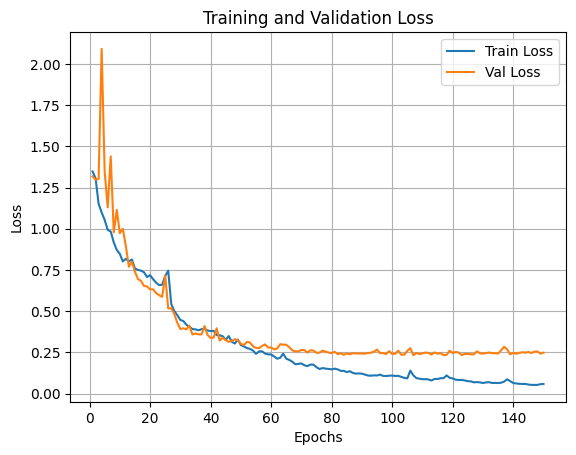

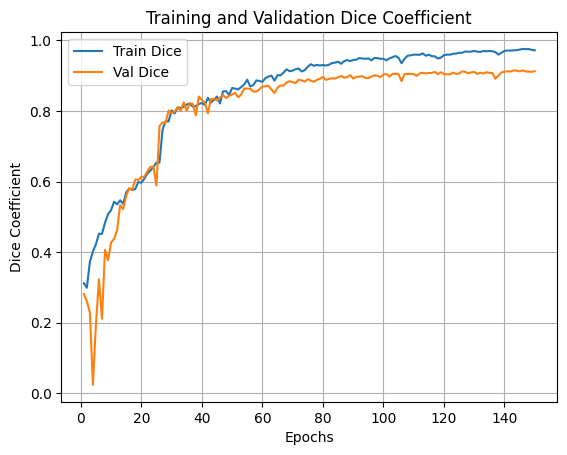

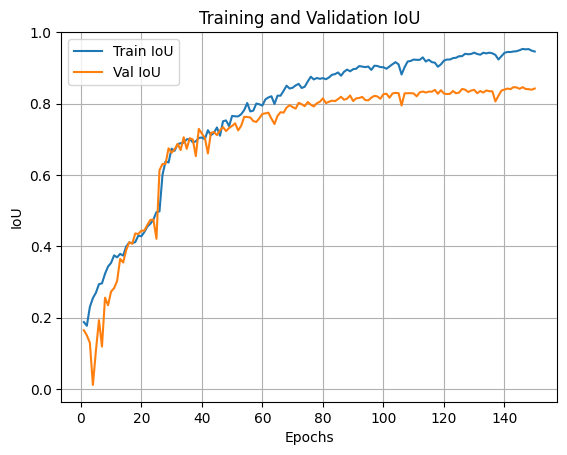

In [15]:
# Access history
history_dict = history.history
epochs = range(1, len(history_dict['loss']) + 1)

# =========================
# Plot Loss
# =========================
plt.figure()
plt.plot(epochs, history_dict['loss'])
plt.plot(epochs, history_dict['val_loss'])
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend(['Train Loss', 'Val Loss'])
plt.grid(True)
plt.show()


# =========================
# Plot Dice Coefficient
# =========================
plt.figure()
plt.plot(epochs, history_dict['dice_coefficient'])
plt.plot(epochs, history_dict['val_dice_coefficient'])
plt.title('Training and Validation Dice Coefficient')
plt.xlabel('Epochs')
plt.ylabel('Dice Coefficient')
plt.legend(['Train Dice', 'Val Dice'])
plt.grid(True)
plt.show()


# =========================
# Plot IoU Metric
# =========================
plt.figure()
plt.plot(epochs, history_dict['iou_metric'])
plt.plot(epochs, history_dict['val_iou_metric'])
plt.title('Training and Validation IoU')
plt.xlabel('Epochs')
plt.ylabel('IoU')
plt.legend(['Train IoU', 'Val IoU'])
plt.grid(True)
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 8s 8s/step


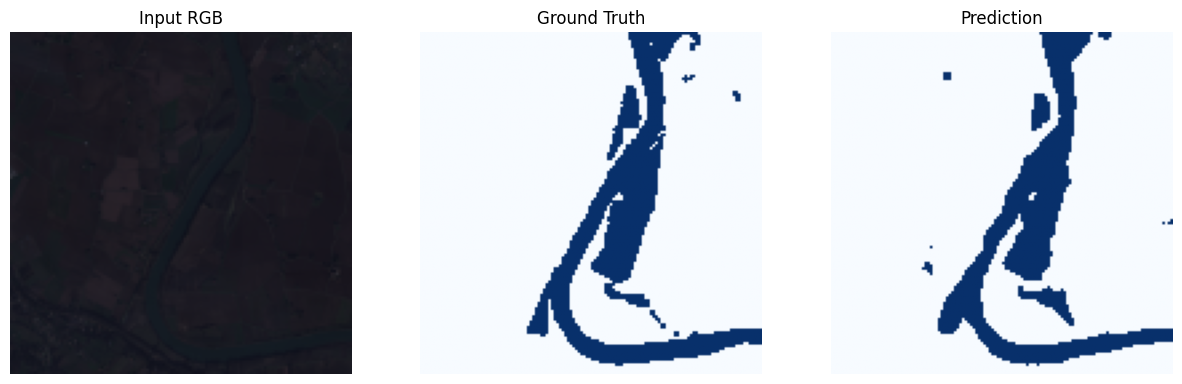

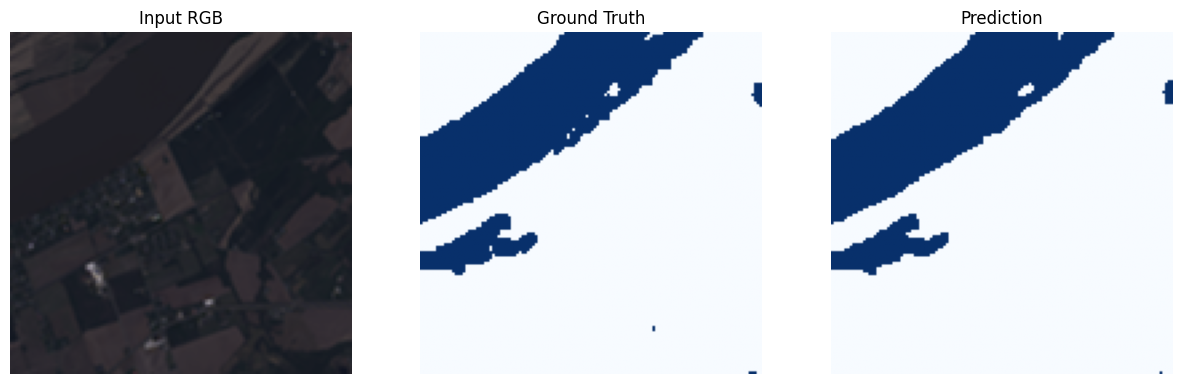

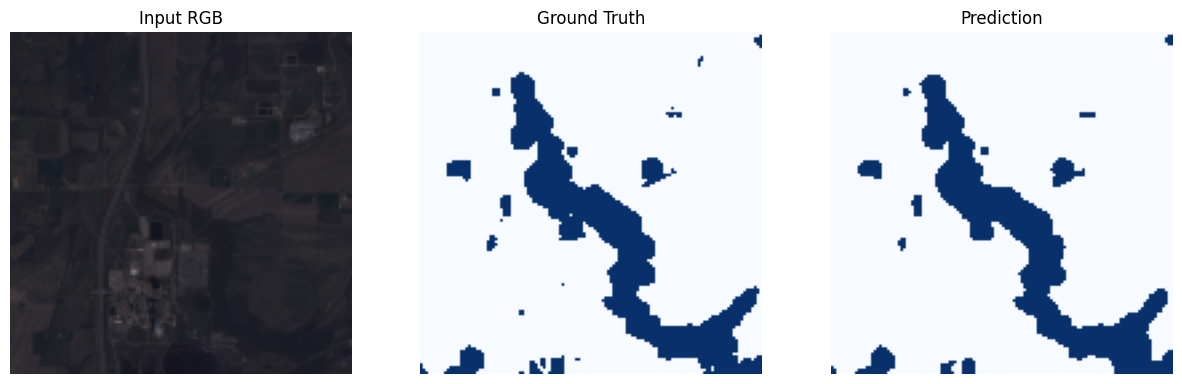

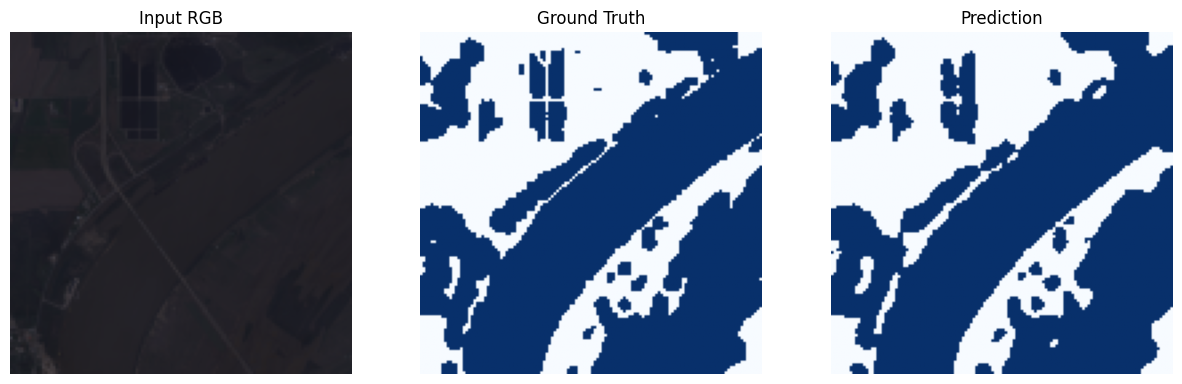

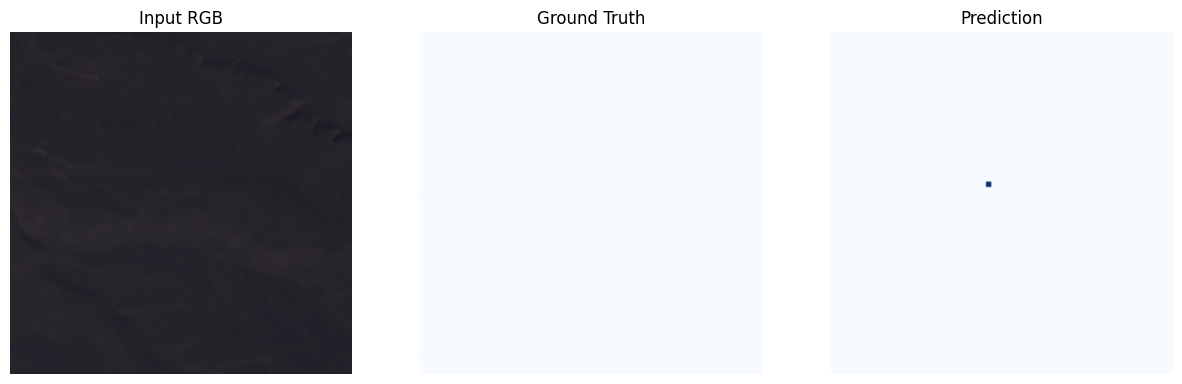

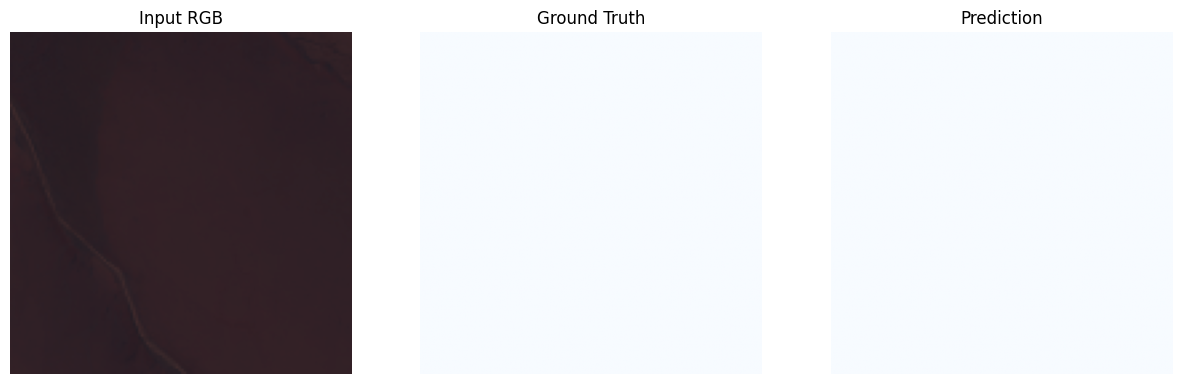

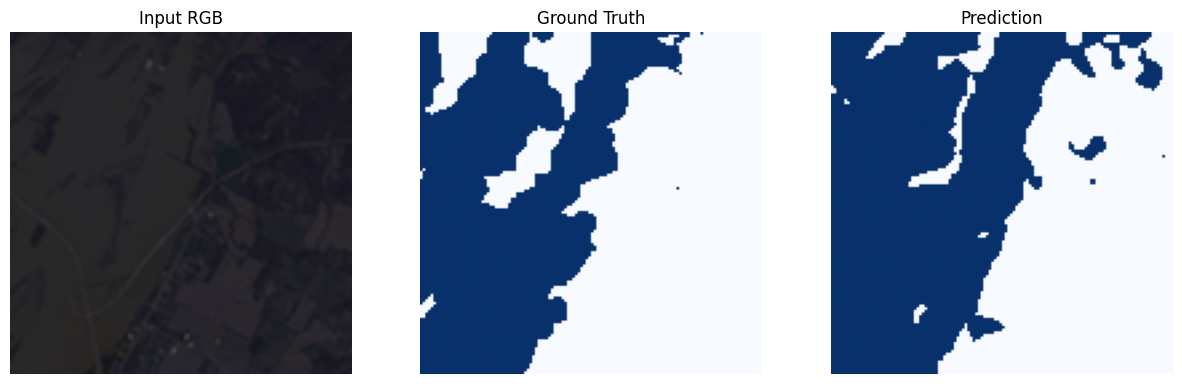

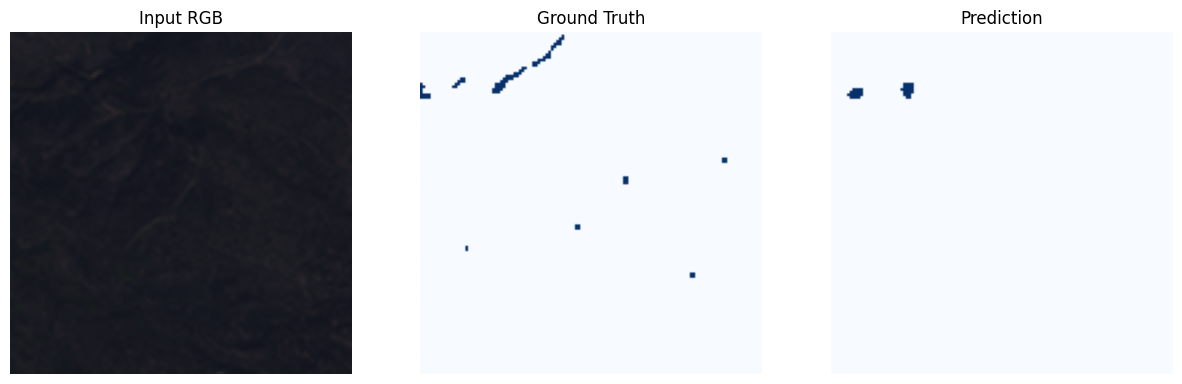

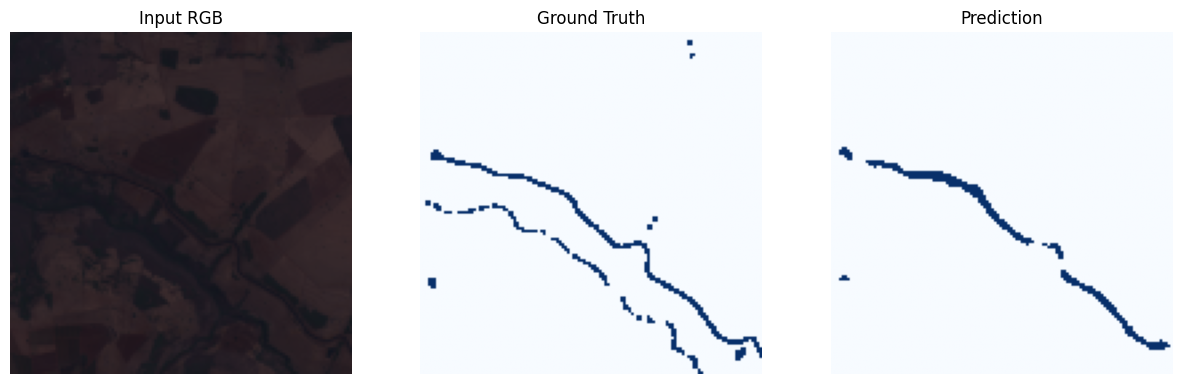

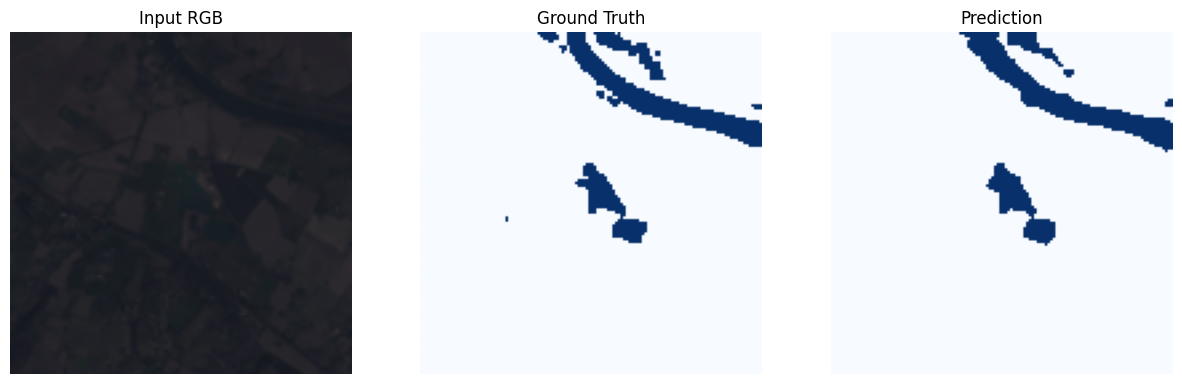

In [16]:
visualize_predictions(model, X_val, y_val, num_samples=10)


In [17]:
# Make predictions on the validation set
y_pred = model.predict(X_val)
y_pred_binary = (y_pred > 0.5).astype(int)

# Flatten the ground truth and predicted masks for metric calculation
y_true_flat = y_val.flatten()
y_pred_flat = y_pred_binary.flatten()

# Calculate F1-score
f1 = f1_score(y_true_flat, y_pred_flat)
print(f"F1 Score: {f1:.4f}")

# Calculate Confusion Matrix
conf_matrix = confusion_matrix(y_true_flat, y_pred_flat)
print("Confusion Matrix:")
print(conf_matrix)

# Calculate Classification Report
class_report = classification_report(y_true_flat, y_pred_flat)
print("\nClassification Report:")
print(class_report)

2/2 ━━━━━━━━━━━━━━━━━━━━ 20s 8s/step
F1 Score: 0.9193
Confusion Matrix:
[[773348  14546]
 [ 21681 206233]]

Classification Report:
              precision    recall  f1-score   support

         0.0       0.97      0.98      0.98    787894
         1.0       0.93      0.90      0.92    227914

    accuracy                           0.96   1015808
   macro avg       0.95      0.94      0.95   1015808
weighted avg       0.96      0.96      0.96   1015808



Investigating adding a single 3 kernel conv layer to transform from 7->3 to feed to the ResNet original input

In [18]:
# ---------------- Input ----------------
inputs = Input((128, 128, 7))

# 7 → 3 projection (This layer WILL be trained)
x = Conv2D(3, 1, padding='same', name="band_projection")(inputs)

# ---------------- Backbone ----------------
base_resnet = ResNet50(
    weights='imagenet',
    include_top=False,
    input_shape=(128, 128, 3)
)

base_resnet.trainable = False

encoder = Model(
    inputs=base_resnet.input,
    outputs=[
        base_resnet.get_layer("conv2_block3_out").output, # c2
        base_resnet.get_layer("conv3_block4_out").output, # c3
        base_resnet.get_layer("conv4_block6_out").output, # c4
        base_resnet.get_layer("conv5_block3_out").output  # c5
    ],
    name="frozen_resnet_encoder"
)

c2, c3, c4, c5 = encoder(x)


u6 = Conv2DTranspose(256, 3, strides=2, padding='same', activation='relu')(c5)
u6 = concatenate([u6, c4])
u6 = Conv2D(256, 3, padding='same', activation='relu')(u6)
u6 = Conv2D(256, 3, padding='same', activation='relu')(u6)

u7 = Conv2DTranspose(128, 3, strides=2, padding='same', activation='relu')(u6)
u7 = concatenate([u7, c3])
u7 = Conv2D(128, 3, padding='same', activation='relu')(u7)
u7 = Conv2D(128, 3, padding='same', activation='relu')(u7)

u8 = Conv2DTranspose(64, 3, strides=2, padding='same', activation='relu')(u7)
u8 = concatenate([u8, c2])
u8 = Conv2D(64, 3, padding='same', activation='relu')(u8)
u8 = Conv2D(64, 3, padding='same', activation='relu')(u8)

u9 = Conv2DTranspose(32, 3, strides=2, padding='same', activation='relu')(u8)
u9 = Conv2D(32, 3, padding='same', activation='relu')(u9)
u9 = Conv2D(32, 3, padding='same', activation='relu')(u9)

u10 = Conv2DTranspose(16, 3, strides=2, padding='same', activation='relu')(u9)
u10 = Conv2D(16, 3, padding='same', activation='relu')(u10)
u10 = Conv2D(16, 3, padding='same', activation='relu')(u10)

outputs = Conv2D(1, 1, activation='sigmoid')(u10)

model2 = Model(inputs, outputs)

model2.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 7)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ band_projection     │ (None, 128, 128,  │         24 │ input_layer_2[0]… │
│ (Conv2D)            │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ frozen_resnet_enco… │ [(None, 32, 32,   │ 23,587,712 │ band_projection[… │
│ (Functional)        │ 256), (None, 16,  │            │                   │
│                     │ 16, 512), (None,  │            │                   │
│                     │ 8, 8, 1024),      │            │                   │
│                     │ (None, 4, 4,      │            │                   │
│                     │ 2048)]            │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_transpose_5  │ (None, 8, 8, 256) │  4,718,848 │ frozen_resnet_en… │
│ (Conv2DTranspose)   │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_4       │ (None, 8, 8,      │          0 │ conv2d_transpose… │
│ (Concatenate)       │ 1280)             │            │ frozen_resnet_en… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_17 (Conv2D)  │ (None, 8, 8, 256) │  2,949,376 │ concatenate_4[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_18 (Conv2D)  │ (None, 8, 8, 256) │    590,080 │ conv2d_17[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_transpose_6  │ (None, 16, 16,    │    295,040 │ conv2d_18[0][0]   │
│ (Conv2DTranspose)   │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_5       │ (None, 16, 16,    │          0 │ conv2d_transpose… │
│ (Concatenate)       │ 640)              │            │ frozen_resnet_en… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_19 (Conv2D)  │ (None, 16, 16,    │    737,408 │ concatenate_5[0]… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_20 (Conv2D)  │ (None, 16, 16,    │    147,584 │ conv2d_19[0][0]   │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_transpose_7  │ (None, 32, 32,    │     73,792 │ conv2d_20[0][0]   │
│ (Conv2DTranspose)   │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_6       │ (None, 32, 32,    │          0 │ conv2d_transpose… │
│ (Concatenate)       │ 320)              │            │ frozen_resnet_en… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_21 (Conv2D)  │ (None, 32, 32,    │    184,384 │ concatenate_6[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_22 (Conv2D)  │ (None, 32, 32,    │     36,928 │ conv2d_21[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_transpose_8  │ (None, 64, 64,    │     18,464 │ conv2d_22[0][0]   │
│ (Conv2DTranspose)   │ 32)               │            │                 

 Total params: 33,367,417 (127.29 MB)

 Trainable params: 9,779,705 (37.31 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [19]:
model2.compile(
    optimizer='adam',
    loss=bce_dice_loss,
    metrics=[dice_coefficient, iou_metric]
)

In [20]:

history2 = model2.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=150,
    batch_size=8
)

Epoch 1/150
31/31 ━━━━━━━━━━━━━━━━━━━━ 35s 567ms/step - dice_coefficient: 0.2911 - iou_metric: 0.1746 - loss: 1.3838 - val_dice_coefficient: 0.2817 - val_iou_metric: 0.1652 - val_loss: 1.3164
Epoch 2/150
31/31 ━━━━━━━━━━━━━━━━━━━━ 2s 60ms/step - dice_coefficient: 0.3264 - iou_metric: 0.1970 - loss: 1.3128 - val_dice_coefficient: 0.2957 - val_iou_metric: 0.1750 - val_loss: 1.3445
Epoch 3/150
31/31 ━━━━━━━━━━━━━━━━━━━━ 2s 58ms/step - dice_coefficient: 0.3114 - iou_metric: 0.1867 - loss: 1.3079 - val_dice_coefficient: 0.2969 - val_iou_metric: 0.1759 - val_loss: 1.3477
Epoch 4/150
31/31 ━━━━━━━━━━━━━━━━━━━━ 2s 59ms/step - dice_coefficient: 0.3107 - iou_metric: 0.1867 - loss: 1.3230 - val_dice_coefficient: 0.2729 - val_iou_metric: 0.1591 - val_loss: 1.3049
Epoch 5/150
31/31 ━━━━━━━━━━━━━━━━━━━━ 2s 59ms/step - dice_coefficient: 0.2872 - iou_metric: 0.1693 - loss: 1.3119 - val_dice_coefficient: 0.2648 - val_iou_metric: 0.1535 - val_loss: 1.2993
Epoch 6/150
31/31 ━━━━━━━━━━━━━━━━━━━━ 2s 62ms/s

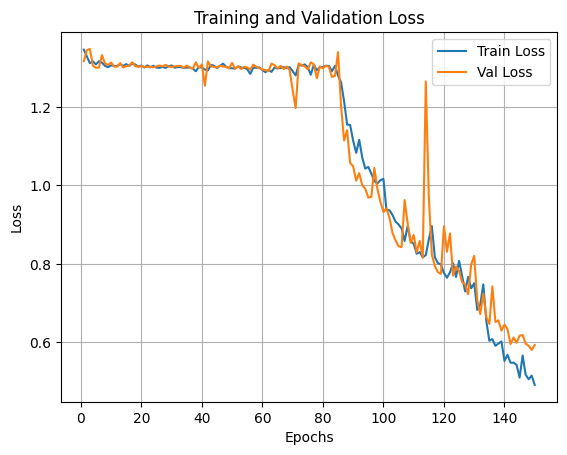

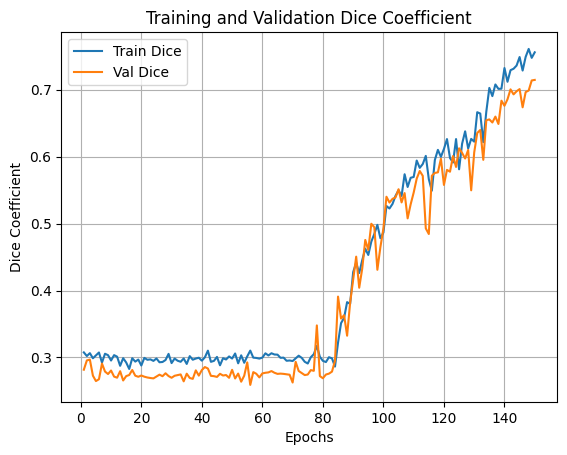

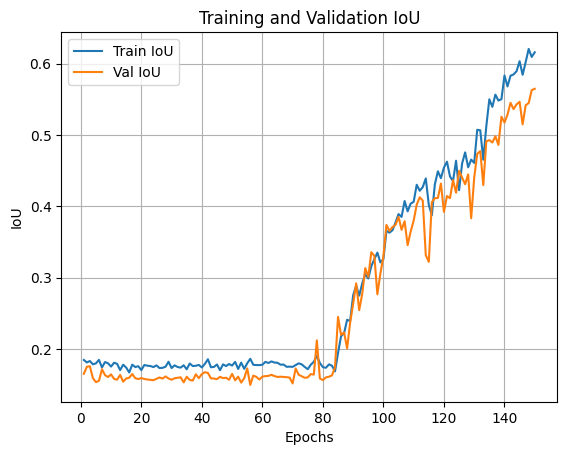

In [21]:
# Access history
history_dict = history2.history
epochs = range(1, len(history_dict['loss']) + 1)

# =========================
# Plot Loss
# =========================
plt.figure()
plt.plot(epochs, history_dict['loss'])
plt.plot(epochs, history_dict['val_loss'])
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend(['Train Loss', 'Val Loss'])
plt.grid(True)
plt.show()


# =========================
# Plot Dice Coefficient
# =========================
plt.figure()
plt.plot(epochs, history_dict['dice_coefficient'])
plt.plot(epochs, history_dict['val_dice_coefficient'])
plt.title('Training and Validation Dice Coefficient')
plt.xlabel('Epochs')
plt.ylabel('Dice Coefficient')
plt.legend(['Train Dice', 'Val Dice'])
plt.grid(True)
plt.show()


# =========================
# Plot IoU Metric
# =========================
plt.figure()
plt.plot(epochs, history_dict['iou_metric'])
plt.plot(epochs, history_dict['val_iou_metric'])
plt.title('Training and Validation IoU')
plt.xlabel('Epochs')
plt.ylabel('IoU')
plt.legend(['Train IoU', 'Val IoU'])
plt.grid(True)
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step


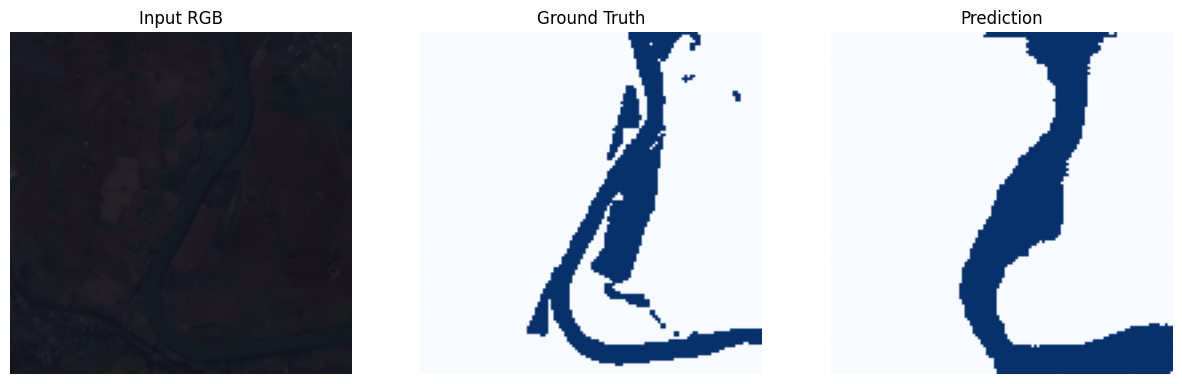

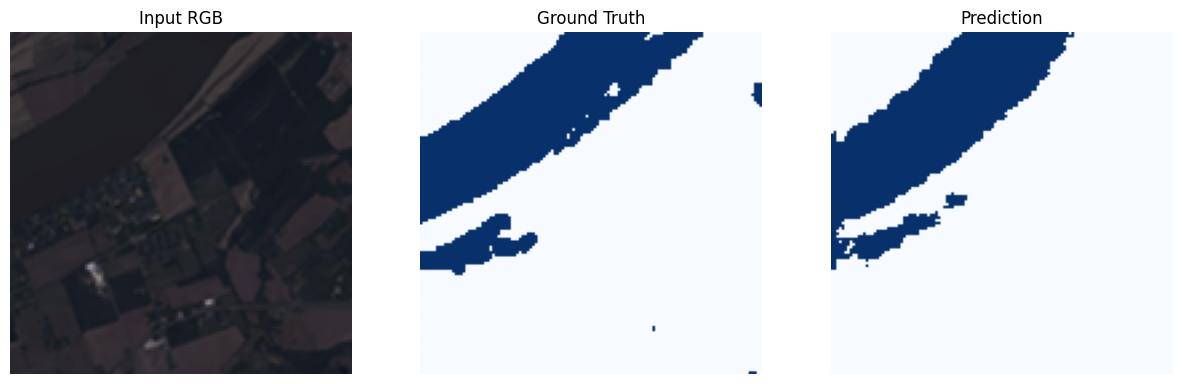

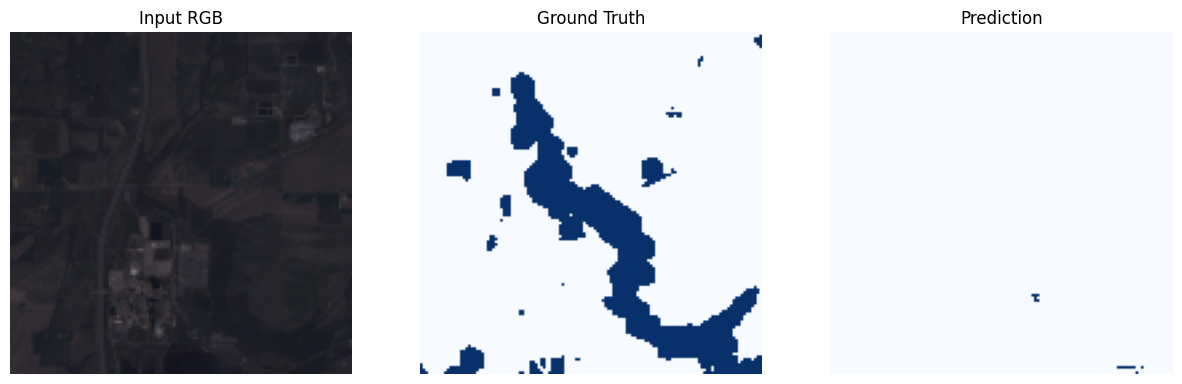

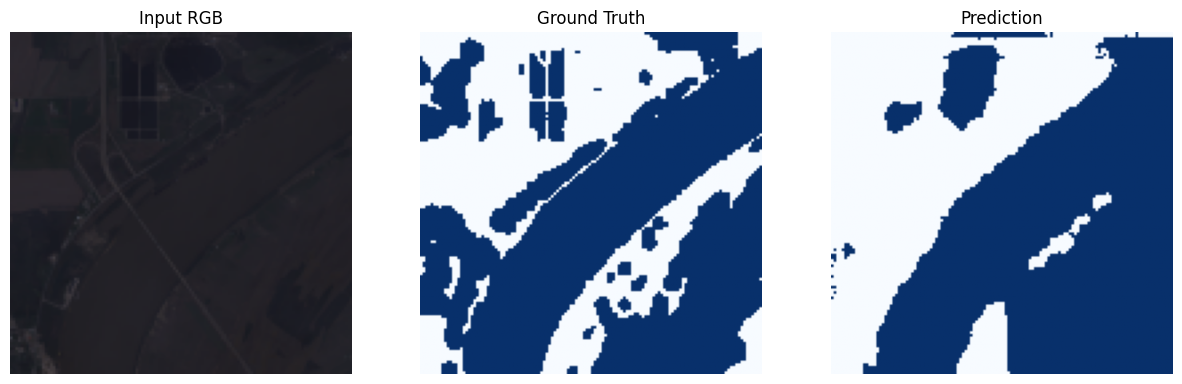

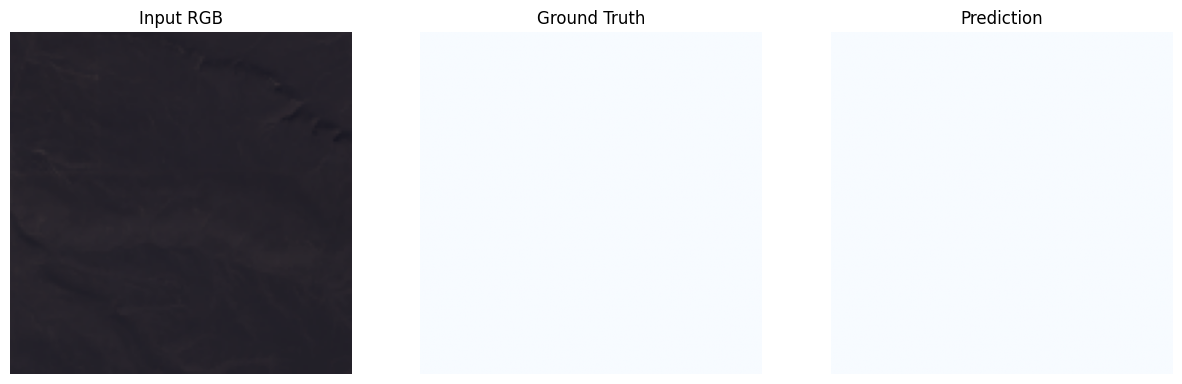

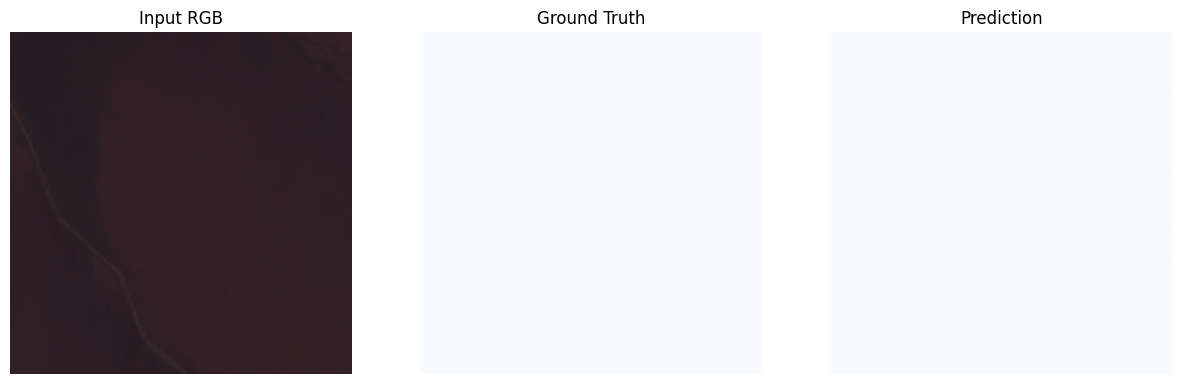

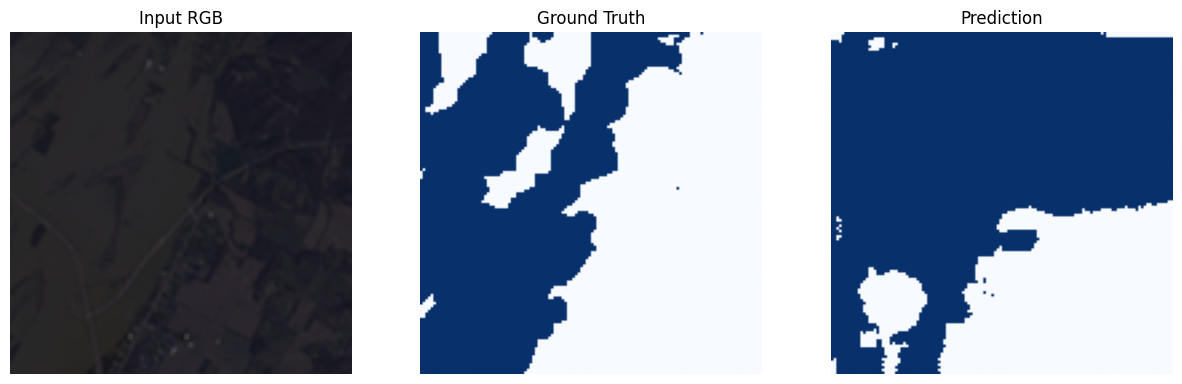

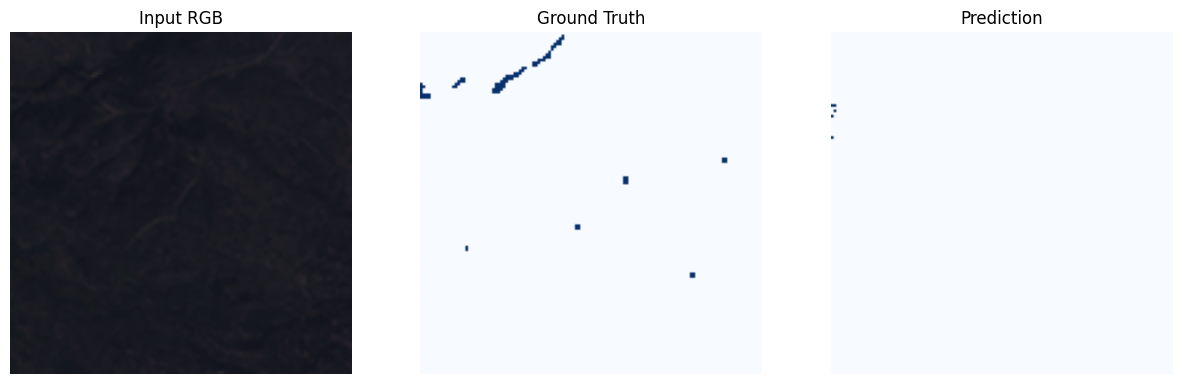

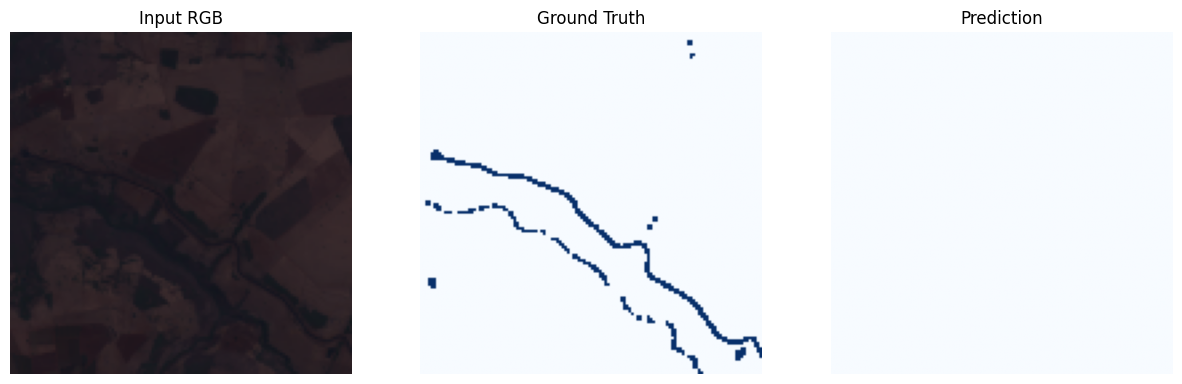

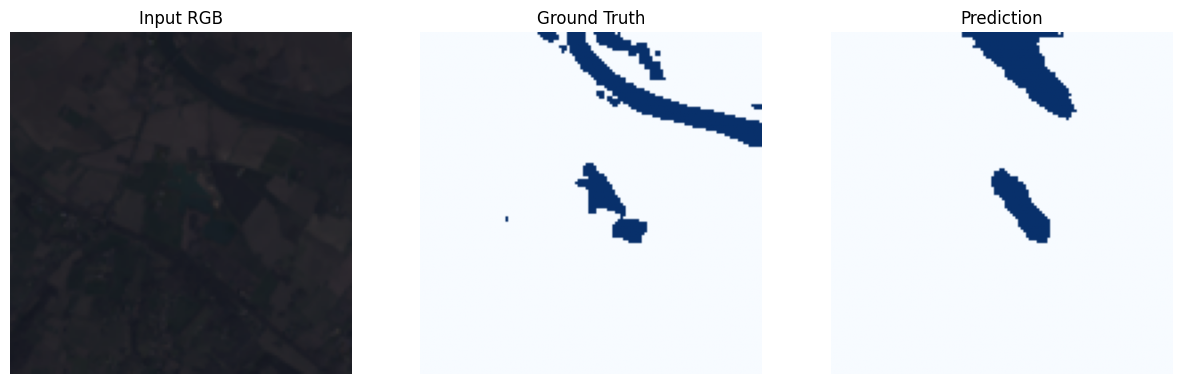

In [39]:
visualize_predictions(model2, X_val, y_val, num_samples=10)


In [23]:
# Make predictions on the validation set
y_pred = model2.predict(X_val)
y_pred_binary = (y_pred > 0.5).astype(int)

# Flatten the ground truth and predicted masks for metric calculation
y_true_flat = y_val.flatten()
y_pred_flat = y_pred_binary.flatten()

# Calculate F1-score
f1 = f1_score(y_true_flat, y_pred_flat)
print(f"F1 Score: {f1:.4f}")

# Calculate Confusion Matrix
conf_matrix = confusion_matrix(y_true_flat, y_pred_flat)
print("Confusion Matrix:")
print(conf_matrix)

# Calculate Classification Report
class_report = classification_report(y_true_flat, y_pred_flat)
print("\nClassification Report:")
print(class_report)

2/2 ━━━━━━━━━━━━━━━━━━━━ 8s 3s/step
F1 Score: 0.7593
Confusion Matrix:
[[720149  67745]
 [ 46964 180950]]

Classification Report:
              precision    recall  f1-score   support

         0.0       0.94      0.91      0.93    787894
         1.0       0.73      0.79      0.76    227914

    accuracy                           0.89   1015808
   macro avg       0.83      0.85      0.84   1015808
weighted avg       0.89      0.89      0.89   1015808

